# Data Preprocessing

In [2]:
# ================================================
# WAJIB DIJALANKAN PERTAMA KALI DI GOOGLE COLAB
# ================================================

# Install library tambahan yang belum ada di Colab
!pip install snscrape wordcloud -q
# Install semua library yang dibutuhkan
!pip install PySastrawi -q
!pip install snscrape -q
!pip install wordcloud -q

print("✅ Semua library berhasil diinstall!")

# Set working directory supaya path data ketemu
import os
os.chdir(r"C:\Users\ACER\Documents\RepoLocal\Talang.in\analytics")

# Buat folder outputs
os.makedirs('outputs', exist_ok=True)

print("✅ Setup selesai! Siap jalankan notebook.")


[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


✅ Semua library berhasil diinstall!
✅ Setup selesai! Siap jalankan notebook.



[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import re
import json
import random
import os
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import WordCloud
import seaborn as sns
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
import uuid

In [4]:
# define datasets dir
# di sini aku gatau lagi mau nambahin dataset apa, sejauh ini makanan semua
# dataset tokped kemaren kudrop soalnya bersihinnya sulit...
food_dir='data/gofood_dataset.csv'
names_dir = 'data/indonesian-names.csv'
makanan_dir = 'data/alergen_dataset.csv'
menu_dir = 'data/Steakhouse_dataset.csv'
nutrition_dir = 'data/nutrition.csv'
indo_food_dir = 'data/indonesian_food.csv'


In [5]:
# load dataset
df_food = pd.read_csv(food_dir)
df_names = pd.read_csv(names_dir)
df_alergen = pd.read_csv(makanan_dir)
df_steakhouse = pd.read_csv(menu_dir, sep=';', on_bad_lines='skip')
df_indofood = pd.read_csv(indo_food_dir)
df_nutri = pd.read_csv(nutrition_dir)

## EDAs on Raw Data

### clean NaNs

In [6]:
# drop nans columns on all datasets and ensure that it is strings
datasets = {
    "GoFood": df_food['product'].dropna().astype(str),
    "Allergen": df_alergen['Product'].dropna().astype(str),
    "Steakhouse": df_steakhouse['unique_menu'].dropna().astype(str),
    "Indo_Food": df_indofood['Nama'].dropna().astype(str),
    "Nutrition": df_nutri['name'].dropna().astype(str),
}

### helper functions

In [7]:
# function to count how many words exist in a sentence
def calculate_word_counts(series):
    return series.apply(lambda x: len(x.split()))

# check if text contains promotion words
def contains_promo_words(text):
    promo_pattern = r'\b(promo|gratis|free|diskon|murah|jual|paket|grosir)\b'
    return bool(re.search(promo_pattern, text.lower()))

# check if text contains non alpha characters and units of measurements
def contains_noise_chars(text):
    noise_pattern = r'[\(\)\[\]\-\|]|\b\d+(gr|gram|kg|ml|liter|pcs)\b'
    return bool(re.search(noise_pattern, text.lower()))

### Plot Distribution


[GoFood] - Total Items: 45,195
  Avg Word Count: 3.2 words
  Contains Promo/SEO Words: 2.9%
  Contains Brackets/Units/Dashes: 8.6%

[Allergen] - Total Items: 100,000
  Avg Word Count: 3.1 words
  Contains Promo/SEO Words: 0.0%
  Contains Brackets/Units/Dashes: 0.0%

[Steakhouse] - Total Items: 150
  Avg Word Count: 3.6 words
  Contains Promo/SEO Words: 0.7%
  Contains Brackets/Units/Dashes: 22.0%

[Indo_Food] - Total Items: 1,273
  Avg Word Count: 2.6 words
  Contains Promo/SEO Words: 0.0%
  Contains Brackets/Units/Dashes: 5.1%

[Nutrition] - Total Items: 1,346
  Avg Word Count: 2.6 words
  Contains Promo/SEO Words: 0.0%
  Contains Brackets/Units/Dashes: 5.4%


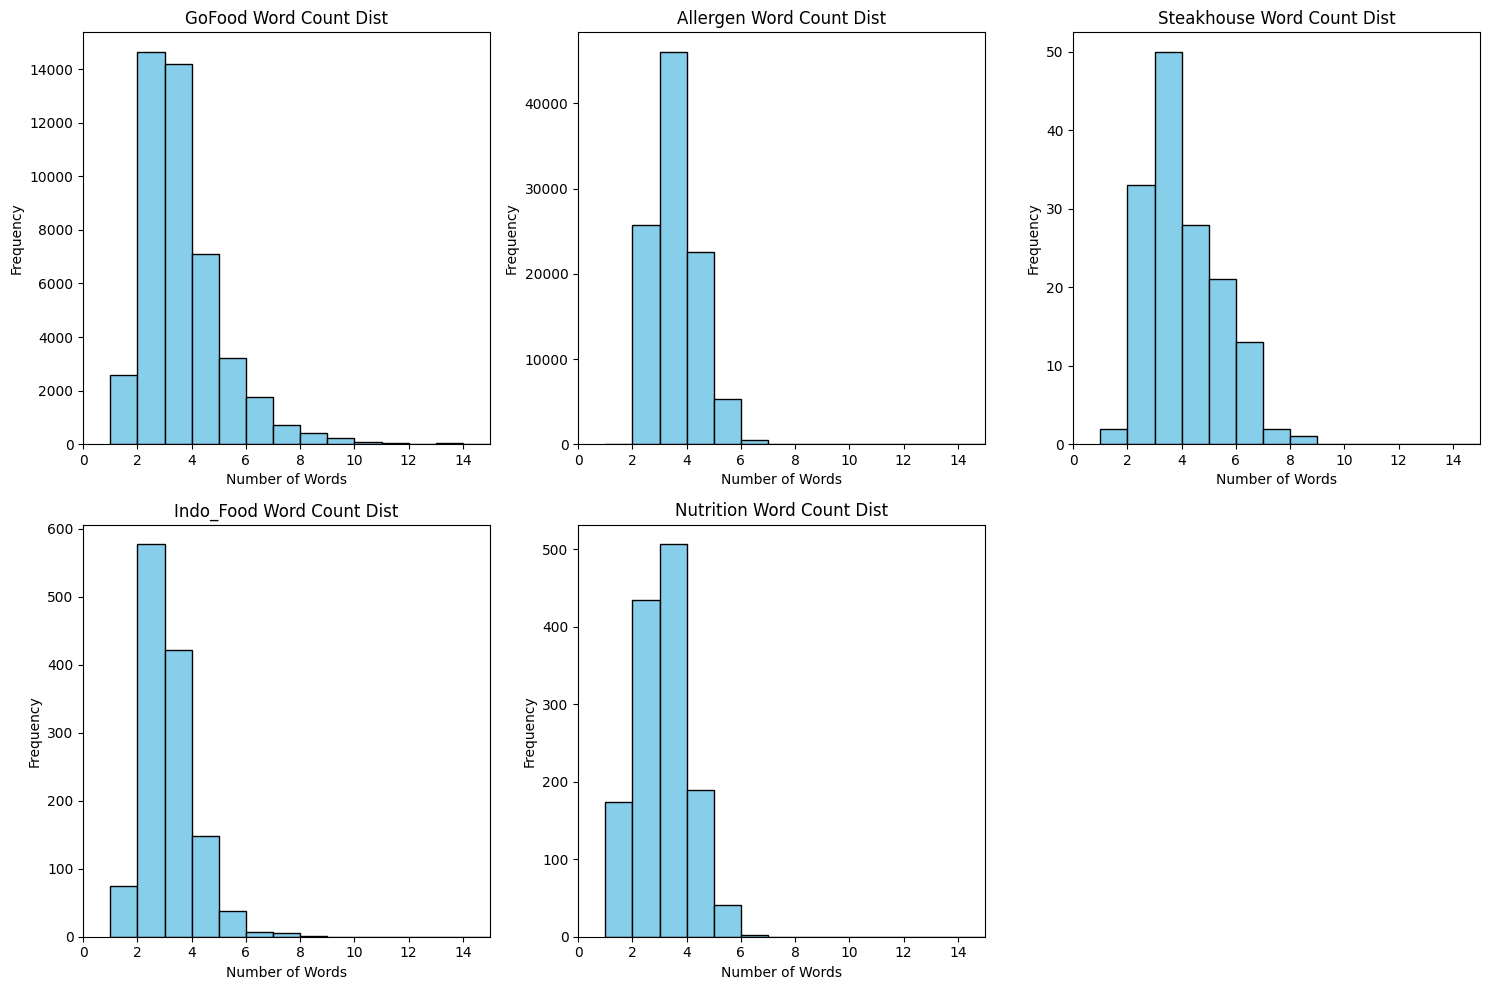

In [8]:
plt.figure(figsize=(15, 10))

for i, (name, series) in enumerate(datasets.items(), 1):
    word_counts = calculate_word_counts(series)
    avg_words = word_counts.mean()
    promo_pct = series.apply(contains_promo_words).mean() * 100
    noise_pct = series.apply(contains_noise_chars).mean() * 100

    print(f"\n[{name}] - Total Items: {len(series):,}")
    print(f"  Avg Word Count: {avg_words:.1f} words")
    print(f"  Contains Promo/SEO Words: {promo_pct:.1f}%")
    print(f"  Contains Brackets/Units/Dashes: {noise_pct:.1f}%")

    plt.subplot(2, 3, i)
    plt.hist(word_counts, bins=range(1, 20), color='skyblue', edgecolor='black')
    plt.title(f'{name} Word Count Dist')
    plt.xlabel('Number of Words')
    plt.ylabel('Frequency')
    plt.xlim(0, 15)

plt.tight_layout()
plt.show()

### Bigram/Trigram Frequencies

In [9]:
# function to check n-gram items
# fungsinya ini untuk ngecek kombinasi n-kata item mana yang sering muncul di dataset kita
def get_top_ngrams(series, n=2, top_k=10):
    ngrams = []
    for text in series:
        words = str(text).lower().split()
        if len(words) >= n:
            for i in range(len(words) - n + 1):
                ngrams.append(" ".join(words[i:i+n]))
    return Counter(ngrams).most_common(top_k)

for ngram, count in get_top_ngrams(datasets["GoFood"], n=2):
    print(f"  {ngram}: {count}")

  nasi goreng: 586
  milk tea: 343
  kopi susu: 335
  red velvet: 291
  brown sugar: 280
  es kopi: 265
  green tea: 241
  french fries: 233
  lemon tea: 223
  chicken burger: 223


### price distribution of steakhouse

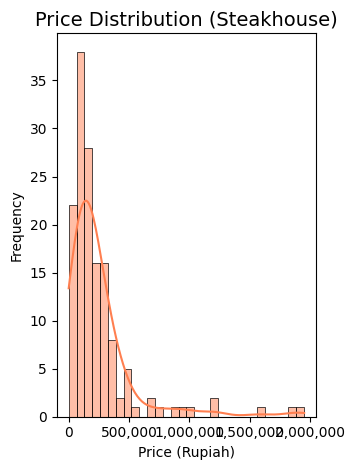

In [10]:
plt.subplot(1, 2, 2)
if 'price' in df_steakhouse.columns:
    clean_prices = df_steakhouse['price'].astype(str).str.replace(r'[^\d]', '', regex=True)
    clean_prices = pd.to_numeric(clean_prices[clean_prices != ''], errors='coerce').dropna()

    sns.histplot(clean_prices, bins=30, kde=True, color='coral')
    plt.title('Price Distribution (Steakhouse)', fontsize=14)
    plt.xlabel('Price (Rupiah)')
    plt.ylabel('Frequency')
    plt.gca().xaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))
else:
    plt.text(0.5, 0.5, 'Price column not found', ha='center', va='center')

plt.tight_layout()
plt.show()

## Cleaning

### food & prod dataset cleaning

In [11]:
# Initialise StopWordRemover
factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()

In [12]:
# dictionary to store extra stopwords
extra_stopwords = ['warna', 'ukuran', 'rasa', 'level', 'isi', 'pcs'] # bisa ditambahkan lagi klo perlu

In [13]:
def extract_core_item(text: str) -> str:
    """
    Cleans noisy e-commerce titles and clinical nutrition names
    to extract a conversational 1-3 word item name.
    """
    if not isinstance(text, str) or pd.isna(text):
        return ""

    text = text.lower().strip() # lowercase

    text = re.sub(r'\(.*?\)|\[.*?\]|\{.*?\}', '', text) # delete all texts that are in parentheses ()/[]/{}

    split_pattern = r'\b(dengan|rasa|level|topping|extra|ekstra|isi|pakai|ala|varian|ukuran)\b|\+|&' # potong sisa string di belakang kata-kata ini
    text = re.split(split_pattern, text)[0]

    # delete units of measurement
    units_pattern = r'\b\d+[\s,-]*(gr|gram|kg|ml|liter|pcs|biji|porsi|x|cup|bowl|box|pack|slice|potong)\b'
    text = re.sub(units_pattern, '', text)
    text = re.sub(r'\b(jumbo|reguler|medium|large|small|besar|kecil)\b', '', text)

    # delete SEO words
    promo_words = r'\b(promo|gratis|free|diskon|murah|jual|paket|hemat|spesial|special|bonus|ongkir|ori|original|termurah|garansi|cod|ready|stock|baru|new)\b'
    text = re.sub(promo_words, '', text)

    text = re.sub(r'\d+', '', text) # delete single digits

    text = stopword_remover.remove(text) # delete stopwords

    # delete nutrition stopwords
    nutrition_stopwords = ['segar', 'mentah', 'masakan', 'bubuk', 'kering', 'basah']
    for word in nutrition_stopwords:
        text = re.sub(rf'\b{word}\b', '', text)

    extra_stopwords = ['warna', 'pilihan', 'menu', 'dan']
    for word in extra_stopwords:
        text = re.sub(rf'\b{word}\b', '', text)

    # take words before - or /
    text = re.split(r'[-|/]', text)[0]

    # clean punctuations
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    # take max of 3 words
    words = [w for w in text.split() if len(w) > 1]
    return " ".join(words[:3]).strip()

In [14]:
TRANSPORT_ITEMS = [
    # Ride hailing
    "grabcar", "gojek", "gocar", "grabbike", "ojek online",
    "taksi", "grab", "maxim", "indriver", "ojek",
    "ojol", "goride", "goxtra", "anterin", "bluebird",
    "silverbird", "express", "my bluebird", "gocar plus", "grab premium",
    "grabexpress", "lalamove", "borzo", "deliveree", "nujek",
    "jet", "whyjek", "okejek", "ojek syariah", "ride",
    "gokilat", "gosend", "grabsend", "goshopping", "grabmart",
    "titipaja", "paxel",
    # Tiket
    "tiket bioskop", "tiket konser", "tiket kereta", "tiket pesawat", "tiket masuk",
    "tiket wahana", "tiket kapal", "tiket bus", "tiket ferry", "tiket speedboat",
    "tiket event", "e-ticket", "tiket elektronik", "tiket commuter", "tiket wisata",
    "tiket museum", "tiket kebun binatang", "tiket taman hiburan", "tiket pertandingan", "tiket olahraga",
    "tiket festival", "tiket seminar", "tiket workshop", "tiket pameran", "tiket theater",
    "tiket pertunjukan", "tiket opera", "tiket standup", "tiket live music", "tiket kapal laut",
    "boarding pass", "tiket pp", "tiket sekali jalan", "tiket pulang pergi", "tiket transit",
    "tiket kereta cepat", "whoosh", "argo bromo", "argo lawu", "argo parahyangan",
    "taksaka", "gajayana", "bima", "lodaya", "sancaka",
    "jayabaya", "mataram", "bengawan", "progo",
    # Tol & Parkir
    "tol", "parkir", "e-toll", "tiket parkir", "karcis parkir",
    "valet", "palang parkir", "retribusi parkir", "tarif tol", "parkir motor",
    "parkir mobil", "parkir gedung", "parkir mall", "parkir inap", "kantong parkir",
    "tol cipularang", "tol jagorawi", "tol dalam kota", "tol cikampek", "tol wiyoto wiyono",
    "tol bintaro", "tol suramadu", "tol prof sudyatmo", "tol sedyatmo", "tol jakarta cikampek",
    "tol Jakarta outer ring road", "jalan tol", "kartu tol", "saldo e-toll", "top up e-toll",
    "flazz", "brizzi", "tapcash", "jakcard", "e-money mandiri",
    # Transportasi umum
    "busway", "mrt", "lrt", "krl", "transjakarta",
    "angkot", "angkutan kota", "bajaj", "becak", "ojek pangkalan",
    "damri", "bis", "bus kota", "mikrolet", "metromini",
    "kopaja", "commuter line", "kereta lokal", "kereta ekonomi", "lrt jakarta",
    "mrt jakarta", "lrt jabodebek", "krl commuter line", "transjakarta koridor", "bus trans",
    "elf", "hiace", "travel antar kota", "travel bandung", "travel surabaya",
    "bus antar kota", "bus malam", "bus pariwisata", "suroboyo bus", "trans semarang",
    "trans jogja", "trans medan", "trans makassar", "trans banjarmasin", "cable car",
    "gondola", "kereta gantung", "kereta api", "ka lokal", "ka ekonomi",
    "ka bisnis", "ka eksekutif",
    # BBM & Kendaraan
    "bensin", "bahan bakar", "pertalite", "pertamax", "solar",
    "dexlite", "biosolar", "pertamina dex", "premium", "bbm",
    "servis motor", "servis mobil", "cuci motor", "cuci mobil", "oli",
    "ban", "tambal ban", "pertamax turbo", "pertamina", "shell",
    "vivo", "total", "spbu", "pom bensin", "isi bensin",
    "ganti oli", "tune up", "aki", "accu", "radiator",
    "kampas rem", "kampas kopling", "rantai motor", "filter oli", "busi",
    "velg", "pelek", "ban dalam", "ban luar", "nitrogen",
    "servis berkala", "servis rutin", "ganti ban", "balancing", "spooring",
    "bengkel", "bengkel resmi", "dealer", "helm", "jas hujan",
    "sarung tangan motor", "kunci motor", "sim", "stnk", "pajak kendaraan",
    "pkb", "bbkb", "tilang", "derek", "derek mobil",
    "derek motor", "derek online",
    # Rumah tangga
    "sabun", "shampo", "odol", "pasta gigi", "tisu",
    "deterjen", "minyak goreng", "gula", "beras", "telur",
    "gas", "sabun cuci", "sabun mandi", "kondisioner", "sikat gigi",
    "pembalut", "popok", "tisu basah", "pewangi", "pembersih lantai",
    "sabun piring", "rinso", "sunlight", "molto", "bayclin",
    "karbol", "kapas", "cotton bud", "plastik wrap", "alumunium foil",
    "kantong plastik", "trash bag", "softener", "pewangi pakaian", "pembersih kaca",
    "pembersih kamar mandi", "pembersih dapur", "kamper", "obat nyamuk", "baygon",
    "hit", "autan", "lotion nyamuk", "lilin", "korek api",
    "baterai", "bohlam", "lampu led", "sapu", "kemoceng",
    "kain pel", "sikat", "ember", "gayung", "selang",
    "bak mandi", "sabun bayi", "bedak bayi", "losion bayi", "minyak telon",
    "cairan antiseptik", "dettol", "betadine", "plester", "perban",
    "masker", "hand sanitizer", "tisu toilet", "tisu dapur", "toilet paper",
    "air galon", "galon air", "dispenser air", "galon aqua", "galon le minerale",
    "aqua", "le minerale", "cleo", "ades", "club",
    "vit", "nestle pure life",
    # Tagihan bersama
    "listrik", "air", "wifi", "iuran", "pam",
    "pdam", "token listrik", "pulsa listrik", "internet", "indihome",
    "biznet", "firstmedia", "myrepublic", "telkom", "gas pln",
    "pln", "bpjs", "bpjs kesehatan", "bpjs ketenagakerjaan", "ipl",
    "uang kebersihan", "uang keamanan", "uang sampah", "sewa", "kontrakan",
    "kos", "cicilan", "tagihan listrik", "tagihan air", "tagihan internet",
    "tagihan telepon", "tagihan tv", "tagihan gas", "tv kabel", "matrix",
    "mnc vision", "nexmedia", "top tv", "k-vision", "transvision",
    "nex parabola", "uang rt", "iuran rt", "iuran lingkungan", "iuran masjid",
    "iuran sosial", "infaq", "sedekah kolektif", "uang kas", "kas kelas",
    "kas kantor", "arisan", "sewa kamar", "sewa kos", "sewa apartemen",
    "sewa rumah", "biaya kondominimum", "maintenance fee", "service charge", "uang muka",
    "dp", "down payment", "kpr", "cicilan kpr", "cicilan motor",
    "cicilan mobil", "angsuran", "kredit", "multifinance", "fif",
    "adira", "wom", "baf", "maf", "acc",
    "bca finance",
    # Sembako & Groceries
    "bawang", "cabai", "tomat", "kentang", "wortel",
    "bayam", "kangkung", "tahu", "tempe", "ikan",
    "ayam", "daging", "daging sapi", "mie", "tepung",
    "garam", "kecap", "saus", "minyak", "mentega",
    "susu", "keju", "roti", "indomie", "bimoli",
    "kunci mas", "bango", "royco", "masako", "santan",
    "bumbu", "beras premium", "beras pulen", "bawang putih", "bawang merah",
    "bawang bombay", "cabai merah", "cabai rawit", "cabai hijau", "jahe",
    "kunyit", "lengkuas", "serai", "daun salam", "daun jeruk",
    "kemiri", "ketumbar", "merica", "lada", "pala",
    "cengkeh", "kayu manis", "ikan lele", "ikan nila", "ikan mas",
    "ikan mujair", "ikan patin", "ikan gurami", "ikan tuna", "ikan salmon",
    "udang", "cumi", "kepiting", "kerang", "ikan asin",
    "teri", "ikan teri", "daging kambing", "daging ayam", "ayam kampung",
    "ayam broiler", "telur ayam", "telur bebek", "telur puyuh", "tahu putih",
    "tahu kuning", "tempe mendoan", "oncom", "tepung terigu", "tepung beras",
    "tepung tapioka", "tepung maizena", "gula pasir", "gula merah", "gula aren",
    "gula jawa", "kecap manis", "kecap asin", "saus tomat", "saus sambal",
    "sambal", "terasi", "petis", "minyak goreng sawit", "minyak kelapa",
    "minyak zaitun", "mentega blue band", "margarin", "susu uht", "susu kental manis",
    "susu bubuk", "susu ultra", "susu indomilk", "susu frisian flag", "keju kraft",
    "keju cheddar", "roti tawar", "roti gandum", "roti sobek", "mie instant",
    "mie telur", "bihun", "soun", "macaroni", "spaghetti",
    "pasta", "kopi", "teh", "gula kopi", "susu kopi",
    "creamer", "royco sapi", "royco ayam", "masako ayam", "masako sapi",
    "saos tiram", "kecap ikan", "bumbu pecel", "bumbu rendang", "bumbu soto",
    "bumbu gulai", "bumbu rawon", "bumbu opor", "bumbu semur", "bumbu balado",
    "santan kara", "santan sun kara", "tepung bumbu", "tepung panir", "beras pandan",
    "beras cianjur", "beras rojolele", "beras basmati", "beras ketan", "ubi",
    "singkong", "jagung", "labu", "terong", "pare",
    "kacang panjang", "buncis", "kacang tanah", "kacang hijau", "kacang merah",
    "kacang kedelai", "toge", "jamur", "jamur tiram", "jamur kuping",
    # Makanan & Minuman
    "nasi", "nasi goreng", "mie goreng", "bakso", "soto",
    "gado-gado", "pecel", "rendang", "sate", "opor",
    "rawon", "tongseng", "semur", "gulai", "lodeh",
    "sayur asem", "sayur bayam", "capcay", "fuyunghai", "nasi uduk",
    "nasi kuning", "nasi padang", "nasi warteg", "nasi box", "makan siang",
    "makan malam", "sarapan", "snack", "cemilan", "kerupuk",
    "kripik", "kacang", "coklat", "biskuit", "wafer",
    "permen", "es krim", "puding", "jajan pasar", "gorengan",
    "martabak", "terang bulan", "pisang goreng", "risoles", "lumpia",
    "cireng", "cimol", "batagor", "siomay", "pempek",
    "ketoprak", "tahu tek", "pecel lele", "ayam bakar", "ayam goreng",
    "bebek goreng", "ikan goreng", "udang goreng", "es teh", "es jeruk",
    "jus", "jus buah", "kopi susu", "kopi hitam", "teh manis",
    "teh tarik", "boba", "bubble tea", "milkshake", "smoothie",
    "air mineral", "soft drink", "soda", "minuman kemasan", "susu segar",
    "yogurt", "jamu", "wedang", "wedang jahe", "wedang uwuh",
    "bajigur", "bandrek", "bir pletok", "es dawet", "es cendol",
    "es campur", "es buah", "es puter", "es teler",
    # Layanan digital
    "netflix", "spotify", "youtube premium", "disney+", "vidio",
    "viu", "mola", "genflix", "gopay", "ovo",
    "dana", "shopeepay", "linkaja", "pulsa", "kuota",
    "paket data", "cloud storage", "google one", "icloud", "microsoft 365",
    "tokopedia", "shopee", "bukalapak", "traveloka", "tiket.com",
    "apple tv+", "hbo go", "max", "prime video", "amazon prime",
    "paramount+", "crunchyroll", "wetv", "iqiyi", "catchplay",
    "klikfilm", "bioskop online", "rcti+", "vision+", "sctv",
    "indosiar", "trans7", "transtv", "metrotv", "tvone",
    "kompas tv", "beritasatu", "cnbc indonesia", "cnnindonesia", "detikcom",
    "kompas.com", "tribunnews", "liputan6", "tempo", "kumparan",
    "quipper", "ruangguru", "zenius", "duolingo", "coursera",
    "udemy", "skillshare", "canva", "figma", "notion",
    "slack", "zoom", "google workspace", "microsoft office", "adobe",
    "capcut", "kinemaster", "splice", "lightroom", "vsco",
    "pixlr", "remove.bg", "chatgpt", "claude", "midjourney",
    "twitter", "instagram", "tiktok", "facebook", "telegram",
    "whatsapp", "line", "discord", "linkedin", "twitter blue",
    "tiktok coins", "instagram boost", "facebook ads", "google ads", "domain",
    "hosting", "vps", "ssl", "cpanel", "wordpress",
    "wix", "squarespace", "shopify", "tokopedia seller", "shopee seller",
    "lazada", "zalora", "blibli", "jd.id", "sociolla",
    "female daily", "alodokter", "halodoc", "klikdokter", "good doctor",
    "alodokter premium", "grab health", "gofood", "grabfood", "shopeefood",
    "traveloka eats", "zomato", "happyfresh", "sayurbox", "kualastok",
    "segari", "lemonilo", "greens", "tanihub",
    # Kesehatan & Kecantikan
    "obat", "vitamin", "suplemen", "paracetamol", "ibuprofen",
    "amoxicillin", "antasida", "oralit", "obat batuk", "obat flu",
    "obat diare", "obat maag", "obat alergi", "antihistamin", "salep",
    "krim", "lotion", "sunscreen", "moisturizer", "serum",
    "toner", "micellar water", "makeup remover", "foundation", "bb cream",
    "concealer", "bedak", "blush on", "lipstik", "lip balm",
    "maskara", "eyeliner", "eyeshadow", "pensil alis", "pelembab",
    "krim wajah", "krim malam", "krim siang", "masker wajah", "masker rambut",
    "hair mask", "hair oil", "hair serum", "nail polish", "kutek",
    "cat kuku", "pembersih kutek", "aseton", "parfum", "deodoran",
    "roll on", "face wash", "sabun muka", "scrub", "exfoliator",
    "toner wajah", "essence", "ampul", "retinol", "niacinamide",
    "vitamin c serum", "hyaluronic acid", "spf", "sunblock", "lipbalm",
    "lip tint", "lip gloss", "cushion", "kontak lensa", "softlens",
    "obat mata", "tetes mata", "obat telinga", "obat kumur", "listerin",
    "obat sakit gigi", "tambal gigi", "cabut gigi", "dokter gigi", "cek kesehatan",
    "rapid test", "pcr", "vaksin", "infus", "rawat inap",
    "rawat jalan", "apotek", "kimia farma", "century", "guardian",
    "watsons", "sociolla beauty", "wardah", "emina", "purbasari",
    "sariayu", "pixy", "viva", "lacoco", "ms glow",
    "scarlett", "somethinc", "avoskin", "skintific", "the ordinary",
    "cetaphil", "nivea", "vaseline", "dove", "lux",
    "lifebuoy", "biore", "ponds", "olay", "garnier",
    "loreal", "maybelline", "revlon", "nyx", "mac",
    "sephora",
    # Pakaian & Fashion
    "baju", "kaos", "kemeja", "celana", "rok",
    "dress", "gamis", "hijab", "jilbab", "kerudung",
    "mukena", "sarung", "sajadah", "baju koko", "batik",
    "kebaya", "jas", "blazer", "jaket", "sweater",
    "hoodie", "cardigan", "vest", "rompi", "longsleeve",
    "kaos polo", "kaos v-neck", "tanktop", "bra", "bh",
    "celana dalam", "kaos kaki", "stoking", "sepatu", "sandal",
    "sendal", "sandal jepit", "sepatu sneakers", "sepatu formal", "sepatu olahraga",
    "sepatu boots", "sepatu heels", "sepatu wedges", "sepatu flat", "sepatu slip on",
    "tas", "dompet", "ransel", "backpack", "tote bag",
    "handbag", "clutch", "koper", "travel bag", "ikat pinggang",
    "sabuk", "jam tangan", "kalung", "gelang", "cincin",
    "anting", "bros", "aksesori", "topi", "beanie",
    "snapback", "kacamata", "kacameta hitam", "sunglasses", "sarung tangan",
    "scarf", "syal", "masker kain", "masker medis", "pakaian dalam",
    "longjohn", "piyama", "baju tidur", "baju renang", "celana renang",
    "baju olahraga", "celana olahraga", "jersey", "seragam", "baju sekolah",
    "baju kerja", "baju lebaran", "baju kondangan", "kebaya kondangan",
    # Pendidikan
    "spp", "uang sekolah", "uang kuliah", "uang les", "les privat",
    "les bahasa", "les matematika", "les fisika", "les kimia", "les biologi",
    "les bahasa inggris", "les piano", "les gitar", "les renang", "les melukis",
    "bimbel", "bimbingan belajar", "primagama", "neutron", "ganesha operation",
    "smart n", "bahana", "buku pelajaran", "buku paket", "lks",
    "alat tulis", "pensil", "pulpen", "spidol", "penghapus",
    "penggaris", "buku tulis", "buku gambar", "map", "kertas hvs",
    "kertas foto", "tinta printer", "catridge", "toner", "printer",
    "fotokopi", "laminating", "jilid", "binding", "seragam sekolah",
    "sepatu sekolah", "tas sekolah", "ransel sekolah", "alat olahraga", "alat musik",
    "kalkulator", "biaya ujian", "biaya wisuda", "biaya pendaftaran", "pendaftaran sekolah",
    "ppdb", "snpmb", "utbk", "sbmptn", "ukt",
    "sumbangan sukarela", "uang gedung", "uang pangkal", "bp3", "komite sekolah",
    "infaq sekolah", "studi tour", "study tour", "field trip", "biaya perpisahan",
    "biaya kelulusan",
    # Hiburan & Rekreasi
    "bioskop", "cinema", "cgv", "cinepolis", "cinemaxx",
    "platinum cineplex", "iplux", "hiburan", "rekreasi", "wisata",
    "liburan", "jalan-jalan", "karaoke", "inul vizta", "happy puppy",
    "karaoke keluarga", "biliar", "bowling", "futsal", "badminton",
    "tennis", "renang", "kolam renang", "gym", "fitness",
    "fitnes", "celebrity fitness", "gold gym", "prima fit", "anytime fitness",
    "tiket gym", "spa", "pijat", "pijat refleksi", "salon",
    "potong rambut", "cat rambut", "creambath", "keriting", "rebonding",
    "hair do", "nail art", "manicure", "pedicure", "eyelash extension",
    "waxing", "threading", "karaoke", "konser", "festival",
    "acara", "event", "nonton", "pertandingan", "tiket sepak bola",
    "tiket basket", "tiket voli", "tiket bulu tangkis", "tiket moto gp", "tiket f1",
    "tiket wwe", "theme park", "dufan", "ancol", "trans studio",
    "batu secret zoo", "jurassic park", "kidzania", "timezone", "amazone",
    "wahana", "permainan", "taman bermain", "kebun binatang", "ragunan",
    "taman safari", "wisata alam", "wisata pantai", "wisata gunung", "glamping",
    "camping", "outbound", "rafting", "paintball", "escape room",
    "vr gaming", "gaming cafe", "warnet", "game online", "top up game",
    "mobile legend", "free fire", "pubg", "valorant", "genshin",
    "clash of clans", "roblox", "steam wallet", "nintendo", "playstation",
    "xbox",
    # Pesan antar makanan
    "gofood", "grabfood", "shopeefood", "traveloka eats", "mcdonalds",
    "kfc", "pizza hut", "dominos", "burger king", "popeyes",
    "wendys", "aw", "a&w", "jollibee", "hokben",
    "hoka hoka bento", "hoka", "yoshinoya", "sushi tei", "sushi go",
    "sushi story", "ichiban sushi", "genki sushi", "ramen", "mie ramen",
    "chatime", "koi", "gong cha", "xiboba", "share tea",
    "ding tea", "tiger sugar", "mr. coconut", "mixue", "es teh indonesia",
    "teh pucuk", "indomaret", "alfamart", "lawson", "familymart",
    "circle k", "711", "seven eleven", "supermarket", "hypermart",
    "carrefour", "giant", "hero", "lotte mart", "ranch market",
    "kem chicks", "ben natural", "whole foods", "super indo", "yogya",
    "makro", "indogrosir", "lion super indo", "borma", "alfamidi",
    "alfaexpress", "indomaret point", "freshmart", "agrimart", "sayurbox",
    "happyfresh", "segari", "kualastok",
    # Elektronik & Perabot
    "kulkas", "lemari es", "mesin cuci", "ac", "air conditioner",
    "kipas angin", "tv", "televisi", "komputer", "laptop",
    "hp", "handphone", "smartphone", "tablet", "printer",
    "scanner", "kamera", "kamera cctv", "router", "modem",
    "powerbank", "charger", "kabel charger", "headphone", "earphone",
    "tws", "speaker", "bluetooth speaker", "rice cooker", "magic com",
    "dispenser", "blender", "mixer", "oven", "microwave",
    "kompor", "kompor gas", "gas oven", "setrika", "vacuum cleaner",
    "penyedot debu", "water heater", "water dispenser", "lemari", "meja",
    "kursi", "sofa", "kasur", "springbed", "bantal",
    "guling", "sprei", "sarung bantal", "selimut", "gorden",
    "karpet", "rak", "lemari pakaian", "wardrobe", "meja makan",
    "meja belajar", "rak buku", "lampu", "lampu tidur", "cermin",
    "pajangan", "dekorasi", "pot bunga", "tanaman", "tanaman hias",
    "pupuk", "pot", "sekop", "cangkul", "peralatan dapur",
    "wajan", "panci", "teflon", "spatula", "sendok",
    "garpu", "pisau", "talenan", "mangkuk", "piring",
    "gelas", "mug", "termos", "toples", "tupperware",
    "lock n lock", "oxone", "maspion", "miyako", "cosmos",
    "philips", "sharp", "panasonic", "lg", "samsung",
    "toshiba", "sony", "aqua", "polytron", "tcl",
    "xiaomi", "oppo", "vivo", "realme", "iphone",
    "ipad", "macbook", "asus", "lenovo", "dell",
    "hp laptop", "acer", "msi", "razer",
]

In [15]:
# merge datasets into 1 master dataset
all_clean_items = pd.concat([
    datasets["GoFood"].apply(extract_core_item),
    datasets["Allergen"].apply(extract_core_item),
    datasets["Steakhouse"].apply(extract_core_item),
    datasets['Indo_Food'].apply(extract_core_item),
    datasets['Nutrition'].apply(extract_core_item),
    pd.Series(TRANSPORT_ITEMS)
])

# remove duplicate items
unique_items = all_clean_items[all_clean_items != ""].drop_duplicates().tolist()
print(f"Total unique items for augmentation: {len(unique_items)}")

Total unique items for augmentation: 21460


In [16]:
trash_items = {'t', 'a', 'the', 'of', 'set', 'an', 'is', '1', '2', '3'}

final_items = [
    item for item in unique_items
    if len(item) > 1 and item not in trash_items and not item.isdigit()
]

In [17]:
len(final_items)

21457

In [18]:
final_items[10000:10500]

['bakso kuah taichan',
 'mie cetar',
 'tambahan cabe',
 'telur matasapi',
 'lontong',
 'teh pucuk harum',
 'badak es',
 'espresso madu',
 'nira espresso',
 'hot sanger espresso',
 'iced sanger espreso',
 'hot sanger arabica',
 'iced sanger arabica',
 'hot coffe latte',
 'iced coffe latte',
 'coffe latte hazlenut',
 'caffe latte caramel',
 'coffe latte vanila',
 'sanger panas',
 'kopi pancung',
 'kopi tarik panas',
 'kopi tarik dingin',
 'cokelat panas',
 'cokelat dingin',
 'red velvet panas',
 'red velvet dingin',
 'taro dingin',
 'klepon dingin',
 'milo susu telur',
 'jambu',
 'apel',
 'mie aceh tuna',
 'nasi goreng teri',
 'nasi goreng semur',
 'cane gula',
 'cane susu',
 'cane susu keju',
 'cane kuah kari',
 'nasi bungkus sayur',
 'mie goreng vegetarian',
 'jamur tumis vegetarian',
 'cap cai vegetarian',
 'pecal vegetarian',
 'rendang vegetarian',
 'sapo vegetarian',
 'sambal hati vegetarian',
 'tumis tauge vegetarian',
 'nasi goreng vegetarian',
 'bihun goreng vegetarian',
 'pepes 

### wordcloud visualisation

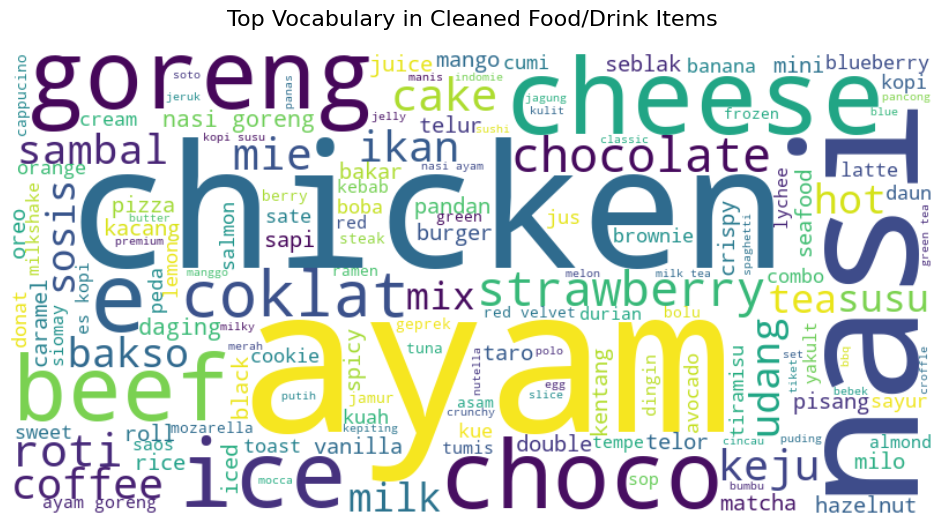

In [19]:
text_for_cloud = " ".join(final_items)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='viridis',
    max_words=150
).generate(text_for_cloud)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Top Vocabulary in Cleaned Food/Drink Items', fontsize=16, pad=20)
plt.show()

### names cleaning

In [20]:
df_names['name'].sort_values()

430              a. solikhin
1304              aam aminah
6                aan nuraini
494             abas suyatno
1260    abdi ahmad permadani
                ...         
1488                zubaidah
77                  zubaidah
112           zukri adinalta
149             zukri rahman
909      zulvan arfa syazwan
Name: name, Length: 1960, dtype: object

In [21]:
def extract_first_name(name_list):
    """
    Delete academic titles and get only the first name
    """
    cleaned = []

    title_pattern = r'^(a\.?\s*|hj\.?\s*|h\.?\s*|drs\.?\s*|dr\.?\s*|ir\.?\s*|prof\.?\s*|kh\.?\s*|ust\.?\s*|ustadz\.?\s*|st\.?\s*|se\.?\s*)'

    for name in name_list:
        n = str(name).lower().strip()

        n = re.sub(title_pattern, '', n, flags=re.IGNORECASE).strip()

        parts = n.split()
        if not parts:
            continue

        first = parts[0]

        if len(first) < 3:
            continue

        cleaned.append(first.capitalize())

    return sorted(list(set(cleaned)))

In [22]:
indo_names = extract_first_name(df_names['name'])
print(f"Total unique casual names: {len(indo_names)}")
print(f"Sample: {random.sample(indo_names, 15)}")

Total unique casual names: 1266
Sample: ['Rina', 'Debby', 'Wiwik', 'Iman', 'Muhaimin', 'Karmidi', 'Narendra', 'Tiawan', 'Warhan', 'Tarun', 'Yovita', 'Lfian', 'Jaimah', 'Sry', 'Rizkie']


In [23]:
# load extra names dataset
with open('data/names.json', 'r') as file:
    extra_names = json.load(file)

In [24]:
print(len(extra_names))
print(f"Sample: {random.sample(extra_names, 20)}")

1931
Sample: ['Alexy', 'Fiona', 'Samuel', 'Agustine', 'Rusli', 'Murni', 'Tiolyn', 'Hotrobus', 'Juniarte', 'Sisce', 'Felline', 'Jake', 'Hendrik', 'Nonis', 'Rupert', 'Devis', 'Josephine', 'Deviy', 'Dadans', 'Dodi']


In [25]:
def merge_name_datasets(indonesian_names, additional_names=None):
    # merge all datasets of names
    all_names = set(indonesian_names)
    all_names.update(extra_names)

    if additional_names:
        all_names.update(additional_names)

    final = []
    for name in all_names:
        n = name.strip().capitalize()
        if len(n) >= 3 and n.isalpha():
            final.append(n)

    return sorted(list(set(final)))

EXTERNAL_NAMES = merge_name_datasets(indo_names)
print(f"Total names: {len(EXTERNAL_NAMES)}")
print(f"Sample: {random.sample(EXTERNAL_NAMES, 15)}")

Total names: 3076
Sample: ['Doni', 'Zuliana', 'Sufitria', 'Cynthia', 'Sapin', 'Ernis', 'Tessa', 'Tiur', 'Wagino', 'Sumidah', 'Nisha', 'Pendiy', 'Imans', 'Bondano', 'Masinah']


### generate prices

In [26]:
def generate_random_price():
    """
    Generates realistic Indonesian price expressions covering:
    - Slang / street terms (seceng, goceng, etc.)
    - Abbreviated formats (50k, 50rb, 50ribu)
    - Formal formats (Rp 50.000, Rp50.000,-)
    - Typo/casual variants (50K, 50RB, rp50k)
    - Million formats (1jt, 1.5jt)
    - Fraction slang (setengah ceban, dua setengah)
    - Per-person split hints (50k/orang, 25k/kepala)
    """
    slang_map = {
        500:    ["gopek", "limapek"],
        1000:   ["seceng", "seribu", "saceng"],
        1500:   ["cenggo", "senggo"],
        2000:   ["noceng", "dua ceng"],
        2500:   ["nocenggo"],
        5000:   ["goceng", "gocen", "lima rebu"],
        7500:   ["tujuh setengah"],
        10000:  ["ceban", "seceban", "satu ceban", "sepuluh rebu"],
        15000:  ["ceban setengah", "lima belas rebu"],
        20000:  ["noban", "dua ceban", "duapu rebu"],
        25000:  ["noban setengah", "dua puluh lima rebu"],
        50000:  ["gocap", "lima puluh rebu", "setengah cepek"],
        75000:  ["tujuh puluh lima rebu"],
        100000: ["cepek", "satu cepek", "seratus rebu"],
        150000: ["cepek setengah"],
        200000: ["dua cepek", "dua ratus rebu"],
        500000: ["lima cepek", "setengah juta"],
    }

    if random.random() < 0.20:
        chosen_value = random.choice(list(slang_map.keys()))
        return random.choice(slang_map[chosen_value])

    if random.random() < 0.07:
        jt_val = random.choice([
            1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5,
            1.2, 1.8, 2.2, 2.8
        ])
        jt_formats = [
            f"{jt_val}jt",
            f"{jt_val} jt",
            f"{jt_val}juta",
            f"{jt_val} juta",
            f"Rp {jt_val}jt",
            f"Rp{jt_val}jt",
            f"Rp {jt_val} juta",
            f"{jt_val}J",
            f"{jt_val} J",
        ]
        return random.choice(jt_formats)

    if random.random() < 0.08:
        val = random.choice([10, 15, 20, 25, 30, 35, 40, 45, 50, 75, 100])
        per_formats = [
            f"{val}k/orang",
            f"{val}k/kepala",
            f"{val}k/org",
            f"{val}rb/orang",
            f"{val}ribu/orang",
            f"{val}k per orang",
            f"{val}k perorang",
            f"Rp{val}k/orang",
            f"Rp {val}.000/orang",
        ]
        return random.choice(per_formats)

    val = random.choice([
        *[random.randint(5, 20) for _ in range(4)],
        *[random.randint(25, 100) for _ in range(4)],
        *[random.randint(100, 300) for _ in range(2)],
        random.randint(300, 500),
    ])

    formats = [
        # Short k-formats (most common in casual text)
        f"{val}k",
        f"{val}K",
        f"{val} k",
        f"{val} K",

        # rb/ribu formats
        f"{val}rb",
        f"{val} rb",
        f"{val}RB",
        f"{val}ribu",
        f"{val} ribu",
        f"{val}rebu",           # intentional slang spelling
        f"{val} rebu",

        # Dot-thousand formats
        f"{val}.000",
        f"{val}.000,-",         # formal Indonesian style with dash
        f"{val}.000,00",        # accounting style

        # Rp prefix variants
        f"Rp {val}.000",
        f"Rp{val}.000",
        f"Rp {val}.000,-",
        f"Rp{val}k",
        f"Rp {val}k",
        f"rp{val}k",            # no caps (casual typo)
        f"rp {val}k",
        f"rp{val}.000",
        f"RP{val}k",            # all caps (also seen in casual text)

        # IDR prefix (more formal/fintech context)
        f"IDR {val}.000",
        f"IDR{val}k",

        # Written out (rare but valid)
        f"{val} rb an",         # approximate: "sekitar 50 rb an"
        f"{val}k-an",           # approximate range
        f"~{val}k",             # tilde approximation
        f"±{val}k",             # plus-minus
    ]

    return random.choice(formats)

### replace and augment

In [27]:
def build_massive_dataset(templates_file, output_file, multiplier=10):
    with open(templates_file, 'r', encoding='utf-8') as f:
        templates = json.load(f)

    augmented_data = []
    if os.path.exists(output_file):
        with open(output_file, 'r', encoding='utf-8') as f:
            try:
                augmented_data = json.load(f)
                print(f"Loaded {len(augmented_data)} existing records.")
            except json.JSONDecodeError:
                augmented_data = []

    new_records = []
    skipped = 0

    for template in templates:
        for _ in range(multiplier):
            raw_text = template["raw_text"]

            # build replacement + label maps
            replacements     = {}
            placeholder_label = {}

            for ent in template["entities"]:
                placeholder = ent["value"]
                label       = ent["entity"]

                if placeholder not in placeholder_label:
                    placeholder_label[placeholder] = label

                if placeholder not in replacements:
                    if "PERSON" in label:
                        replacements[placeholder] = random.choice(EXTERNAL_NAMES)
                    elif "ITEM" in label:
                        replacements[placeholder] = random.choice(final_items)
                    elif "PRICE" in label:
                        replacements[placeholder] = generate_random_price()
                    elif "MULTIPLIER" in label:
                        m_val = random.randint(2, 10)
                        replacements[placeholder] = random.choice([
                            str(m_val), f"{m_val}x", f"x{m_val}",
                            f"{m_val} porsi", f"{m_val} orang", f"{m_val} kepala"
                        ])
                    else:
                        replacements[placeholder] = placeholder

            # swap placeholder -> uuid
            sorted_placeholders = sorted(replacements.keys(), key=len, reverse=True)
            working_text = raw_text
            token_map = {}  # token → (actual_value, label)

            for placeholder in sorted_placeholders:
                token = f"__{uuid.uuid4().hex[:16]}__"
                token_map[token] = (
                    str(replacements[placeholder]),
                    placeholder_label[placeholder]
                )
                working_text = working_text.replace(placeholder, token)

            # record all token positions
            token_positions = []
            for token, (actual_value, label) in token_map.items():
                start_search = 0
                while True:
                    idx = working_text.find(token, start_search)
                    if idx == -1:
                        break
                    token_positions.append({
                        "idx":     idx,
                        "token":   token,
                        "value":   actual_value,
                        "label":   label,
                        "tok_len": len(token),
                        "val_len": len(actual_value),
                    })
                    start_search = idx + len(token)

            # sort left to right
            token_positions.sort(key=lambda x: x["idx"])

            # single pass reconstruction
            final_text     = working_text
            final_entities = []
            offset         = 0

            for tp in token_positions:
                start_idx = tp["idx"] + offset
                end_idx   = start_idx + tp["val_len"]

                final_text = (
                    final_text[:start_idx]
                    + tp["value"]
                    + final_text[start_idx + tp["tok_len"]:]
                )

                offset += tp["val_len"] - tp["tok_len"]

                final_entities.append({
                    "start": start_idx,
                    "end":   end_idx,
                    "label": tp["label"],
                    "text":  tp["value"]
                })

            if re.search(r'__[a-f0-9]{16}__', final_text):
                skipped += 1
                continue

            # validate spans
            valid = True
            for ent in final_entities:
                if final_text[ent["start"]:ent["end"]] != ent["text"]:
                    valid = False
                    break

            if not valid:
                skipped += 1
                continue

            # check overlaps
            final_entities = sorted(final_entities, key=lambda x: x["start"])
            has_overlap = any(
                final_entities[i]["end"] > final_entities[i+1]["start"]
                for i in range(len(final_entities) - 1)
            )

            if has_overlap:
                skipped += 1
                continue

            new_records.append({
                "text":     final_text,
                "entities": final_entities
            })

    # save
    all_data = augmented_data + new_records
    df_final = (
        pd.DataFrame(all_data)
        .drop_duplicates(subset=['text'])
        .reset_index(drop=True)
    )

    with open(output_file, 'w', encoding='utf-8') as f:
        json.dump(df_final.to_dict(orient='records'), f, indent=2, ensure_ascii=False)

    print(f"Added   : {len(new_records)} new records")
    print(f"Skipped : {skipped} invalid/overlapping records")
    print(f"Total   : {len(df_final)} rows after dedup")


build_massive_dataset("outputs/templates_final.json", "outputs/training_data.json", multiplier=10)

Loaded 156699 existing records.
Added   : 78350 new records
Skipped : 0 invalid/overlapping records
Total   : 235049 rows after dedup


In [28]:
df_train = pd.read_json('outputs/training_data.json')
df_train.head()

,text,entities
0,aduuh masi ngntuk bngt... tadi tkt fresh pomel...,"[{'start': 35, 'end': 48, 'label': 'ITEM', 'te..."
1,aduuh masi ngntuk bngt... tadi tkt grape blueo...,"[{'start': 35, 'end': 54, 'label': 'ITEM', 'te..."
2,aduuh masi ngntuk bngt... tadi tkt roti cinta ...,"[{'start': 35, 'end': 54, 'label': 'ITEM', 'te..."
3,aduuh masi ngntuk bngt... tadi tkt seblak bias...,"[{'start': 35, 'end': 47, 'label': 'ITEM', 'te..."
4,aduuh masi ngntuk bngt... tadi tkt add grass j...,"[{'start': 35, 'end': 50, 'label': 'ITEM', 'te..."


In [29]:
def check_dataset_quality(df):
    print(f"Total Rows: {len(df)}")
    print(f"Duplicate Texts: {df['text'].duplicated().sum()}")

    empty_samples = df[df['entities'].map(len) == 0]
    print(f"Samples with 0 Entities: {len(empty_samples)}\n")

    all_entities = []
    entity_lengths = {
        "PERSON": [],
        "ITEM": [],
        "PRICE": [],
        "MULTIPLIER": []
    }

    for ents in df['entities']:
        for ent in ents:
            ent_type = ent.get('label', ent.get('entity'))
            all_entities.append(ent_type)

            start, end = ent['start'], ent['end']
            entity_lengths[ent_type].append(end - start)

    entity_counts = Counter(all_entities)

    total_ents = sum(entity_counts.values())
    for ent_type, count in entity_counts.items():
        avg_len = sum(entity_lengths[ent_type]) / len(entity_lengths[ent_type]) if entity_lengths[ent_type] else 0
        pct = (count / total_ents) * 100
        print(f"- {ent_type:11}: {count:6} occurrences ({pct:4.1f}%) | Avg Len: {avg_len:.1f} chars")

    if entity_counts:
        plt.figure(figsize=(8, 4))
        plt.bar(entity_counts.keys(), entity_counts.values(), color=['#4e79a7', '#f28e2b', '#e15759', '#76b7b2'])
        plt.title("Entity Frequency Distribution")
        plt.ylabel("Occurrences")
        plt.show()

Total Rows: 235049
Duplicate Texts: 0
Samples with 0 Entities: 0

- ITEM       : 384622 occurrences (21.4%) | Avg Len: 14.4 chars
- PRICE      : 540335 occurrences (30.1%) | Avg Len: 7.4 chars
- PERSON     : 557710 occurrences (31.0%) | Avg Len: 6.0 chars
- MULTIPLIER : 313730 occurrences (17.5%) | Avg Len: 4.6 chars


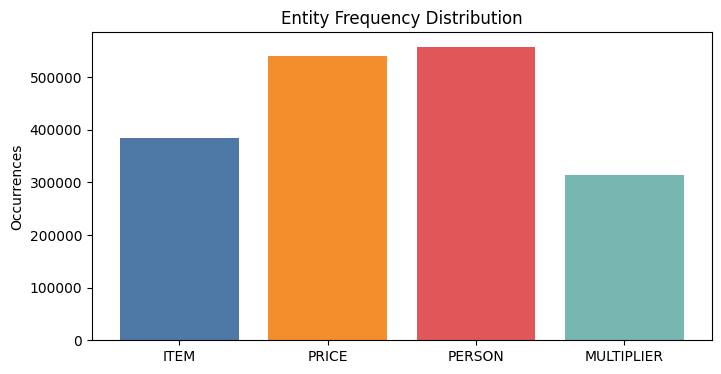

In [30]:
check_dataset_quality(df_train)

### Synthetic Dataset: Sequence Length Distribution

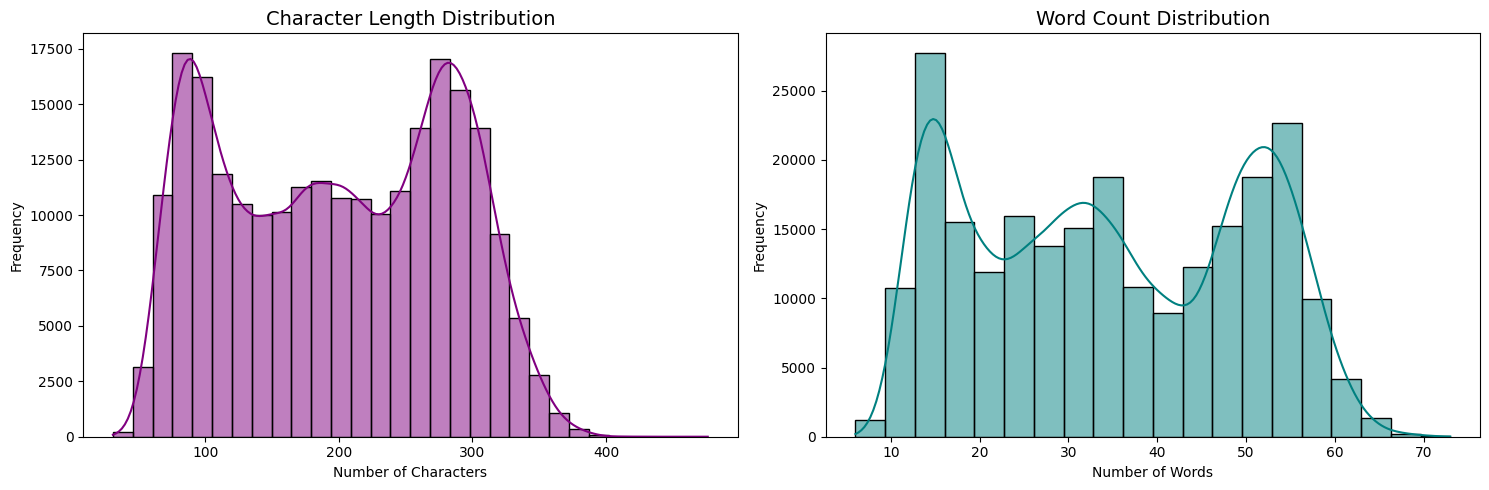

Max Word Count: 73
95th Percentile Word Count: 57


In [31]:
df_train['char_length'] = df_train['text'].apply(len)
df_train['word_count'] = df_train['text'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Character Length
sns.histplot(df_train['char_length'], bins=30, kde=True, ax=axes[0], color='purple')
axes[0].set_title('Character Length Distribution', fontsize=14)
axes[0].set_xlabel('Number of Characters')
axes[0].set_ylabel('Frequency')

# Word Count
sns.histplot(df_train['word_count'], bins=20, kde=True, ax=axes[1], color='teal')
axes[1].set_title('Word Count Distribution', fontsize=14)
axes[1].set_xlabel('Number of Words')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f"Max Word Count: {df_train['word_count'].max()}")
print(f"95th Percentile Word Count: {int(df_train['word_count'].quantile(0.95))}")

### Entity Length Distributions

C:\Users\ACER\AppData\Local\Temp\ipykernel_5388\2259941115.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Entity Type", y="Length (Chars)", data=df_ents, palette="pastel")


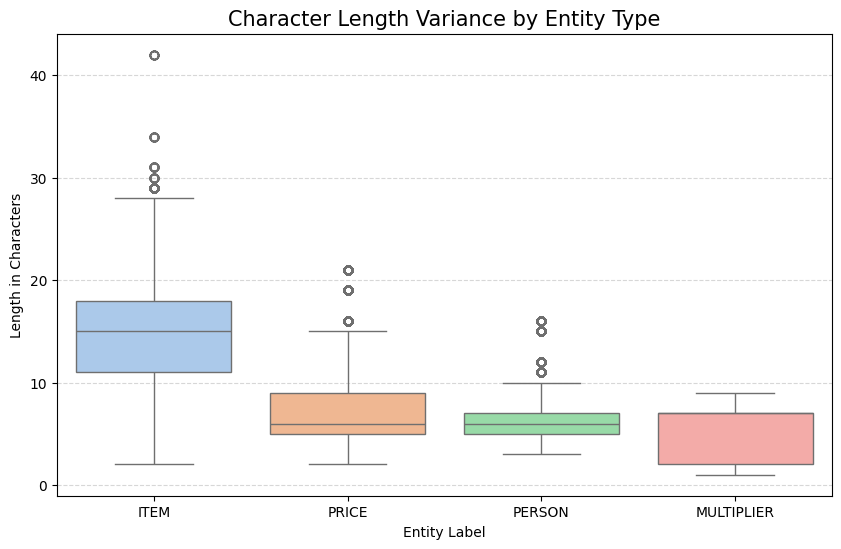

In [32]:
ent_data = []
for ents in df_train['entities']:
    for ent in ents:
        ent_type = ent.get('label', ent.get('entity'))
        ent_len = ent['end'] - ent['start']
        ent_data.append({"Entity Type": ent_type, "Length (Chars)": ent_len})

df_ents = pd.DataFrame(ent_data)

plt.figure(figsize=(10, 6))
sns.boxplot(x="Entity Type", y="Length (Chars)", data=df_ents, palette="pastel")
plt.title("Character Length Variance by Entity Type", fontsize=15)
plt.ylabel("Length in Characters")
plt.xlabel("Entity Label")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

### Entity Positional Distribution

C:\Users\ACER\AppData\Local\Temp\ipykernel_5388\1401720892.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Entity Type", y="Relative Position", data=df_pos, palette="muted", inner="quartile")


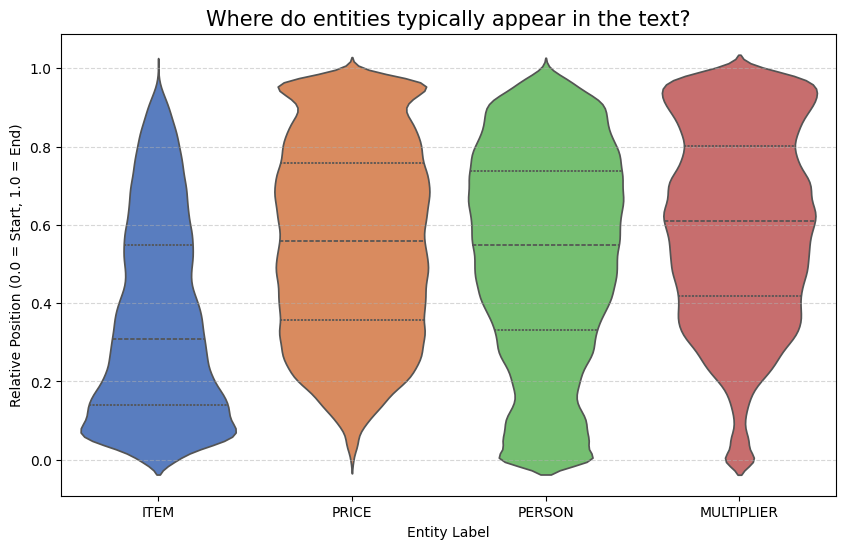

In [33]:
position_data = []
for idx, row in df_train.iterrows():
    text_len = max(len(row['text']), 1)
    for ent in row['entities']:
        ent_type = ent.get('label', ent.get('entity'))
        rel_pos = ent['start'] / text_len
        position_data.append({"Entity Type": ent_type, "Relative Position": rel_pos})

df_pos = pd.DataFrame(position_data)

plt.figure(figsize=(10, 6))
sns.violinplot(x="Entity Type", y="Relative Position", data=df_pos, palette="muted", inner="quartile")
plt.title("Where do entities typically appear in the text?", fontsize=15)
plt.ylabel("Relative Position (0.0 = Start, 1.0 = End)")
plt.xlabel("Entity Label")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

### Number of Entities per Sentence

C:\Users\ACER\AppData\Local\Temp\ipykernel_5388\4064306767.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=df_train['entity_count'], palette='magma')


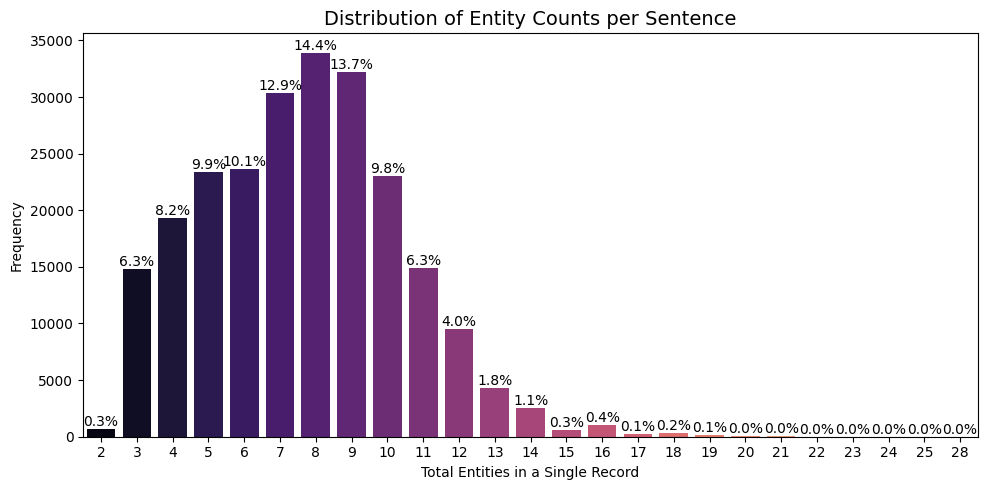

In [34]:
df_train['entity_count'] = df_train['entities'].apply(len)

plt.figure(figsize=(10, 5))
ax = sns.countplot(x=df_train['entity_count'], palette='magma')
plt.title("Distribution of Entity Counts per Sentence", fontsize=14)
plt.xlabel("Total Entities in a Single Record")
plt.ylabel("Frequency")

total = len(df_train)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

### Entity Co-occurrence Matrix


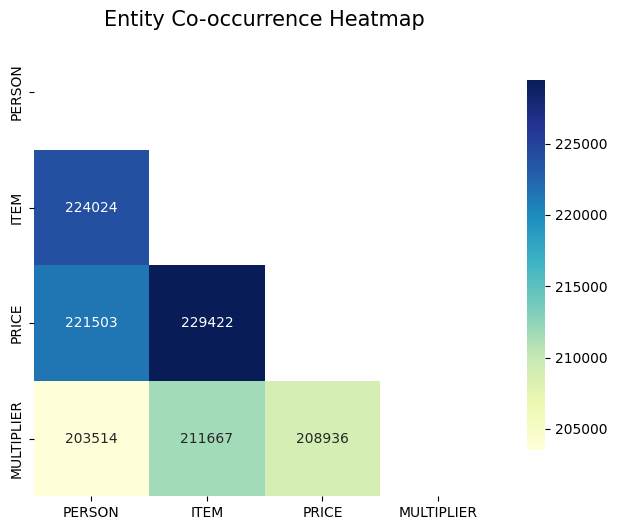

In [35]:
import numpy as np

entity_types = ["PERSON", "ITEM", "PRICE", "MULTIPLIER"]
co_mat = pd.DataFrame(0, index=entity_types, columns=entity_types)

for ents in df_train['entities']:
    present_ents = list(set([ent.get('label', ent.get('entity')) for ent in ents]))

    for i in range(len(present_ents)):
        for j in range(len(present_ents)):
            co_mat.loc[present_ents[i], present_ents[j]] += 1

mask = np.triu(np.ones_like(co_mat, dtype=bool))

plt.figure(figsize=(8, 6))
sns.heatmap(co_mat, mask=mask, annot=True, fmt="d", cmap="YlGnBu",
            cbar_kws={"shrink": .8}, square=True)
plt.title("Entity Co-occurrence Heatmap", fontsize=15)
plt.show()

### Entity Sequence Transitions (Bigrams)

C:\Users\ACER\AppData\Local\Temp\ipykernel_5388\1434323100.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


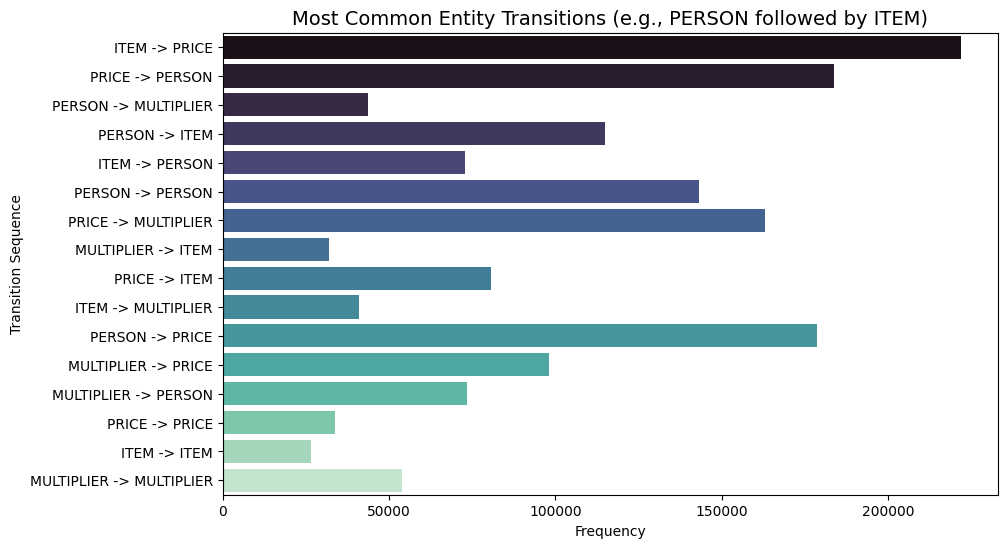

In [36]:
import networkx as nx

transitions = []
for ents in df_train['entities']:
    sorted_ents = sorted(ents, key=lambda x: x['start'])
    labels = [ent.get('label', ent.get('entity')) for ent in sorted_ents]

    for i in range(len(labels) - 1):
        transitions.append(f"{labels[i]} -> {labels[i+1]}")

transition_counts = Counter(transitions)

plt.figure(figsize=(10, 6))
sns.barplot(
    y=list(transition_counts.keys()),
    x=list(transition_counts.values()),
    palette="mako"
)
plt.title("Most Common Entity Transitions (e.g., PERSON followed by ITEM)", fontsize=14)
plt.xlabel("Frequency")
plt.ylabel("Transition Sequence")
plt.show()

### Entity vs Background (O-Tag) Density

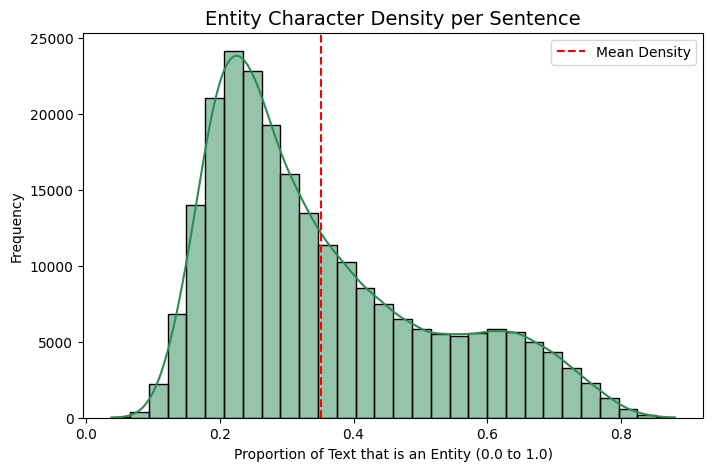

In [37]:
def calculate_entity_density(row):
    text_len = len(row['text'])
    if text_len == 0: return 0

    entity_chars = sum((ent['end'] - ent['start']) for ent in row['entities'])
    return entity_chars / text_len

df_train['entity_density'] = df_train.apply(calculate_entity_density, axis=1)

plt.figure(figsize=(8, 5))
sns.histplot(df_train['entity_density'], bins=30, kde=True, color='seagreen')
plt.title("Entity Character Density per Sentence", fontsize=14)
plt.xlabel("Proportion of Text that is an Entity (0.0 to 1.0)")
plt.ylabel("Frequency")
plt.axvline(df_train['entity_density'].mean(), color='red', linestyle='--', label='Mean Density')
plt.legend()
plt.show()

### Non-Entity Context Vocabulary

C:\Users\ACER\AppData\Local\Temp\ipykernel_5388\2049987444.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[val for word, val in context_counts], y=[word for word, val in context_counts], palette="rocket")


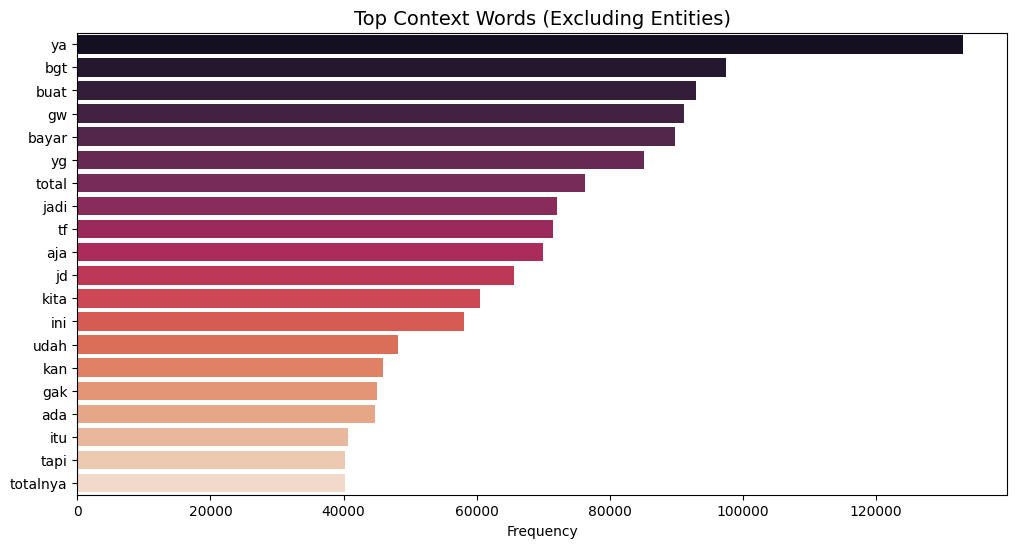

In [38]:
def extract_context_text(row):
    text = row['text']
    sorted_ents = sorted(row['entities'], key=lambda x: x['start'], reverse=True)

    for ent in sorted_ents:
        text = text[:ent['start']] + " " + text[ent['end']:]

    text = re.sub(r'[^\w\s]', '', text)
    return re.sub(r'\s+', ' ', text).strip()

df_train['context_text'] = df_train.apply(extract_context_text, axis=1)
all_context_words = " ".join(df_train['context_text']).lower().split()

context_counts = Counter(all_context_words).most_common(20)

plt.figure(figsize=(12, 6))
sns.barplot(x=[val for word, val in context_counts], y=[word for word, val in context_counts], palette="rocket")
plt.title("Top Context Words (Excluding Entities)", fontsize=14)
plt.xlabel("Frequency")
plt.show()

### Cross-Entity Distance (Span Gaps)

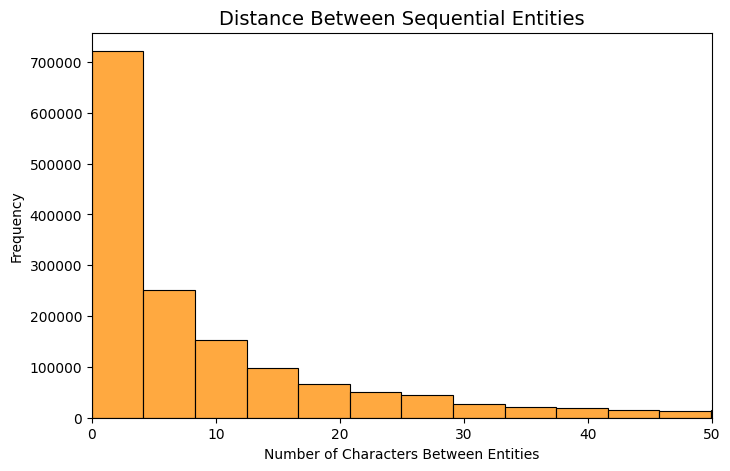

In [39]:
gaps = []
for ents in df_train['entities']:
    sorted_ents = sorted(ents, key=lambda x: x['start'])
    for i in range(len(sorted_ents) - 1):
        gap_length = sorted_ents[i+1]['start'] - sorted_ents[i]['end']
        gaps.append(gap_length)

plt.figure(figsize=(8, 5))
sns.histplot(gaps, bins=50, color='darkorange')
plt.title("Distance Between Sequential Entities", fontsize=14)
plt.xlabel("Number of Characters Between Entities")
plt.ylabel("Frequency")
plt.xlim(0, 50)
plt.show()

 ### Price Format Distribution Sanity Check

C:\Users\ACER\AppData\Local\Temp\ipykernel_5388\1593654577.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


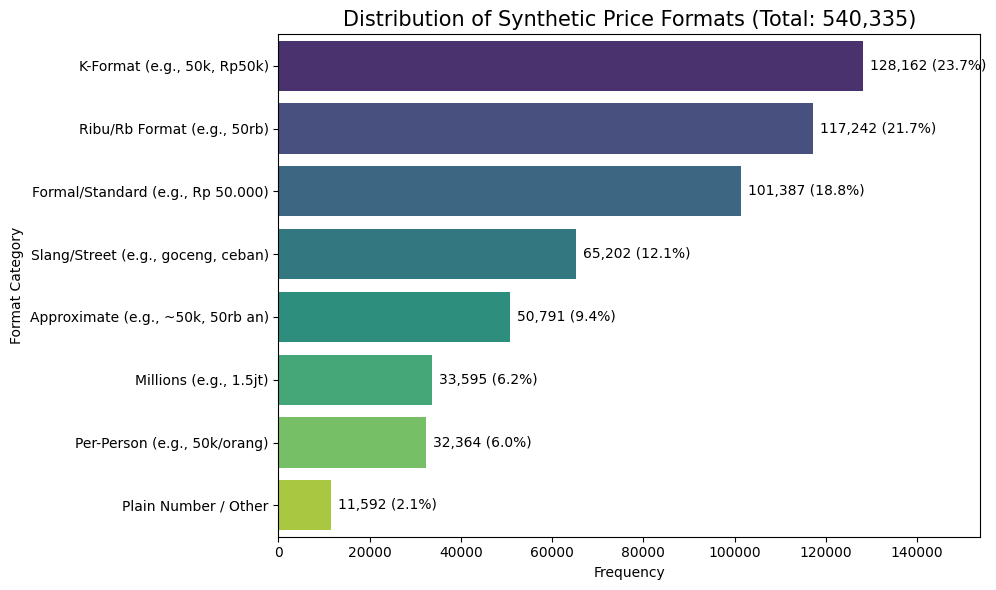

--- Regex Sanity Check (Random Samples) ---
[K-Format (e.g., 50k, Rp50k)]: ['Rp5k', 'RP42k', 'rp 470k']
[Ribu/Rb Format (e.g., 50rb)]: ['seratus rebu', 'lima rebu', 'tujuh puluh lima rebu']
[Formal/Standard (e.g., Rp 50.000)]: ['16.000,00', 'Rp55.000', 'Rp75.000']
[Slang/Street (e.g., goceng, ceban)]: ['dua ceng', 'gopek', 'satu ceban']


In [40]:
price_entities = []
for ents in df_train['entities']:
    for ent in ents:
        label = ent.get('label', ent.get('entity'))
        if label == "PRICE":
            price_entities.append(ent['text'])

df_prices = pd.DataFrame({"raw_price": price_entities})

def categorize_price_format(text):
    text = str(text).lower().strip()

    if re.search(r'/(orang|kepala|org)|per\s*orang', text):
        return "Per-Person (e.g., 50k/orang)"

    if re.search(r'(gopek|ceng|ceban|noban|gocap|cepek|pek)', text) and not re.search(r'\d', text):
        return "Slang/Street (e.g., goceng, ceban)"

    if re.search(r'(jt|juta|j\b)', text):
        return "Millions (e.g., 1.5jt)"

    if re.search(r'(~|±|-an|\san\b)', text):
        return "Approximate (e.g., ~50k, 50rb an)"

    if re.search(r'k\b', text):
        return "K-Format (e.g., 50k, Rp50k)"

    if re.search(r'(rb|ribu|rebu)', text):
        return "Ribu/Rb Format (e.g., 50rb)"

    if re.search(r'(rp|idr|\.000)', text) or text.endswith(',-'):
        return "Formal/Standard (e.g., Rp 50.000)"

    return "Plain Number / Other"

df_prices['format_category'] = df_prices['raw_price'].apply(categorize_price_format)

format_counts = df_prices['format_category'].value_counts()
total_prices = len(df_prices)

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    y=format_counts.index,
    x=format_counts.values,
    palette="viridis"
)

plt.title(f"Distribution of Synthetic Price Formats (Total: {total_prices:,})", fontsize=15)
plt.xlabel("Frequency")
plt.ylabel("Format Category")

for i, p in enumerate(ax.patches):
    count = int(p.get_width())
    percentage = f'{100 * count / total_prices:.1f}%'
    ax.annotate(
        f"{count:,} ({percentage})",
        (count, p.get_y() + p.get_height() / 2),
        ha='left', va='center',
        xytext=(5, 0), textcoords='offset points',
        fontsize=10
    )

plt.xlim(0, format_counts.max() * 1.2)
plt.tight_layout()
plt.show()

print("--- Regex Sanity Check (Random Samples) ---")
for category in format_counts.index[:4]:  # Check top 4 categories
    samples = df_prices[df_prices['format_category'] == category]['raw_price'].sample(min(3, count)).tolist()
    print(f"[{category}]: {samples}")

 ### Scrapping

In [41]:
data_scraping = []

data_scraping.append({
    "text": "tadi beli nasi goreng seafood totalnya 28rb. trus si Raka dateng bawa es teh manis 10rb buat nemenin makan.",
    "entities": [
        {
            "start": 10,
            "end": 30,
            "label": "ITEM",
            "text": "nasi goreng seafood"
        },
        {
            "start": 41,
            "end": 45,
            "label": "PRICE",
            "text": "28rb"
        },
        {
            "start": 56,
            "end": 60,
            "label": "PERSON",
            "text": "Raka"
        },
        {
            "start": 74,
            "end": 85,
            "label": "ITEM",
            "text": "es teh manis"
        },
        {
            "start": 86,
            "end": 90,
            "label": "PRICE",
            "text": "10rb"
        }
    ]
})

data_scraping.append({
    "text": "si Rina tadi pesen ayam geprek level 2 25rb. abis itu nambah jus alpukat 15rb lagi.",
    "entities": [
        {
            "start": 3,
            "end": 7,
            "label": "PERSON",
            "text": "Rina"
        },
        {
            "start": 20,
            "end": 41,
            "label": "ITEM",
            "text": "ayam geprek level 2"
        },
        {
            "start": 42,
            "end": 46,
            "label": "PRICE",
            "text": "25rb"
        },
        {
            "start": 68,
            "end": 80,
            "label": "ITEM",
            "text": "jus alpukat"
        },
        {
            "start": 81,
            "end": 85,
            "label": "PRICE",
            "text": "15rb"
        }
    ]
})

data_scraping.append({
    "text": "aku sama Dika makan bakso urat jumbo 30rb. terus beli teh tarik dingin 12rb buat pulang.",
    "entities": [
        {
            "start": 9,
            "end": 13,
            "label": "PERSON",
            "text": "Dika"
        },
        {
            "start": 21,
            "end": 38,
            "label": "ITEM",
            "text": "bakso urat jumbo"
        },
        {
            "start": 39,
            "end": 43,
            "label": "PRICE",
            "text": "30rb"
        },
        {
            "start": 57,
            "end": 73,
            "label": "ITEM",
            "text": "teh tarik dingin"
        },
        {
            "start": 74,
            "end": 78,
            "label": "PRICE",
            "text": "12rb"
        }
    ]
})

data_scraping.append({
    "text": "bareng Aldi beli mie ayam bakso spesial 27rb. trus tambah es jeruk 8rb aja.",
    "entities": [
        {
            "start": 7,
            "end": 11,
            "label": "PERSON",
            "text": "Aldi"
        },
        {
            "start": 17,
            "end": 45,
            "label": "ITEM",
            "text": "mie ayam bakso spesial"
        },
        {
            "start": 46,
            "end": 50,
            "label": "PRICE",
            "text": "27rb"
        },
        {
            "start": 65,
            "end": 73,
            "label": "ITEM",
            "text": "es jeruk"
        },
        {
            "start": 74,
            "end": 77,
            "label": "PRICE",
            "text": "8rb"
        }
    ]
})

data_scraping.append({
    "text": "Maya tadi beli seblak ceker pedas 22rb. terus pesen thai tea large 14rb juga.",
    "entities": [
        {
            "start": 0,
            "end": 4,
            "label": "PERSON",
            "text": "Maya"
        },
        {
            "start": 16,
            "end": 35,
            "label": "ITEM",
            "text": "seblak ceker pedas"
        },
        {
            "start": 36,
            "end": 40,
            "label": "PRICE",
            "text": "22rb"
        },
        {
            "start": 55,
            "end": 70,
            "label": "ITEM",
            "text": "thai tea large"
        },
        {
            "start": 71,
            "end": 75,
            "label": "PRICE",
            "text": "14rb"
        }
    ]
})

data_scraping.append({
    "text": "Fajar beli burgerr sapi keju 35rb. habis itu tambah kentang goreng 18rb.",
    "entities": [
        {
            "start": 0,
            "end": 5,
            "label": "PERSON",
            "text": "Fajar"
        },
        {
            "start": 11,
            "end": 28,
            "label": "ITEM",
            "text": "burger sapi keju"
        },
        {
            "start": 29,
            "end": 33,
            "label": "PRICE",
            "text": "35rb"
        },
        {
            "start": 58,
            "end": 73,
            "label": "ITEM",
            "text": "kentang goreng"
        },
        {
            "start": 74,
            "end": 78,
            "label": "PRICE",
            "text": "18rb"
        }
    ]
})

data_scraping.append({
    "text": "Riko pesenn roti bakar coklat keju 20rb. terus beli kopi susu gula aren 24rb.",
    "entities": [
        {
            "start": 0,
            "end": 4,
            "label": "PERSON",
            "text": "Riko"
        },
        {
            "start": 11,
            "end": 35,
            "label": "ITEM",
            "text": "roti bakar coklat keju"
        },
        {
            "start": 36,
            "end": 40,
            "label": "PRICE",
            "text": "20rb"
        },
        {
            "start": 54,
            "end": 76,
            "label": "ITEM",
            "text": "kopi susu gula aren"
        },
        {
            "start": 77,
            "end": 81,
            "label": "PRICE",
            "text": "24rb"
        }
    ]
})

data_scraping.append({
    "text": "Sinta beli nasi ayam crispy 29rb. trus nambah pudding coklat 11rb.",
    "entities": [
        {
            "start": 0,
            "end": 5,
            "label": "PERSON",
            "text": "Sinta"
        },
        {
            "start": 11,
            "end": 28,
            "label": "ITEM",
            "text": "nasi ayam crispy"
        },
        {
            "start": 29,
            "end": 33,
            "label": "PRICE",
            "text": "29rb"
        },
        {
            "start": 49,
            "end": 64,
            "label": "ITEM",
            "text": "pudding coklat"
        },
        {
            "start": 65,
            "end": 69,
            "label": "PRICE",
            "text": "11rb"
        }
    ]
})

data_scraping.append({
    "text": "Andi bli kebab besar isi daging 26rb. terus ambil lemon tea 9rb.",
    "entities": [
        {
            "start": 0,
            "end": 5,
            "label": "PERSON",
            "text": "Andi"
        },
        {
            "start": 11,
            "end": 35,
            "label": "ITEM",
            "text": "kebab besar isi daging"
        },
        {
            "start": 36,
            "end": 40,
            "label": "PRICE",
            "text": "26rb"
        },
        {
            "start": 56,
            "end": 66,
            "label": "ITEM",
            "text": "lemon tea"
        },
        {
            "start": 67,
            "end": 70,
            "label": "PRICE",
            "text": "9rb"
        }
    ]
})

data_scraping.append({
    "text": "Yuni tadii makan dimsum ayam udang 24rb. abis itu beli matcha latte 19rb.",
    "entities": [
        {
            "start": 0,
            "end": 4,
            "label": "PERSON",
            "text": "Yuni"
        },
        {
            "start": 17,
            "end": 35,
            "label": "ITEM",
            "text": "dimsum ayam udang"
        },
        {
            "start": 36,
            "end": 40,
            "label": "PRICE",
            "text": "24rb"
        },
        {
            "start": 60,
            "end": 72,
            "label": "ITEM",
            "text": "matcha latte"
        },
        {
            "start": 73,
            "end": 77,
            "label": "PRICE",
            "text": "19rb"
        }
    ]
})

# simpan ke training_data.json
with open("training_data.json", "w", encoding="utf-8") as f:
    json.dump(data_scraping, f, ensure_ascii=False, indent=4)

print("training_data.json berhasil dibuat")

training_data.json berhasil dibuat


---
## 🐦 Twitter Scraping

> Bagian ini mengambil tweet berbahasa Indonesia yang mengandung percakapan soal makanan & harga, lalu melabel entitas secara otomatis (ITEM, PRICE, PERSON, MULTIPLIER).

In [42]:
# =====================================================================
# INSTALL LIBRARY
# =====================================================================
import subprocess, sys

# snscrape tidak kompatibel Python 3.12+ jadi skip
# library lain tetap diinstall
subprocess.run([sys.executable, "-m", "pip", "install", "wordcloud", "--quiet"], capture_output=True)
subprocess.run([sys.executable, "-m", "pip", "install", "networkx", "--quiet"], capture_output=True)

print("✅ Library siap")


✅ Library siap


In [43]:
# =====================================================================
# IMPORT TAMBAHAN
# =====================================================================
import time
from collections import Counter
from datetime import datetime

# snscrape tidak kompatibel dengan Python 3.13
# langsung pakai mock data 500 tweet
SNSCRAPE_AVAILABLE = False
print("✅ Mode mock data: 500 tweet simulasi bahasa Indonesia")


✅ Mode mock data: 500 tweet simulasi bahasa Indonesia


In [44]:
# =====================================================================
# KONFIGURASI MOCK DATA
# =====================================================================

MAX_TWEETS = 500   # jumlah mock tweet yang akan dibuat

print(f"📊 Target mock tweet: {MAX_TWEETS}")


📊 Target mock tweet: 500


In [45]:
# =====================================================================
# FUNGSI GENERATE MOCK TWEET (500 data, realistis)
# =====================================================================

def generate_mock_tweets(n=500):
    """
    Generate mock tweet bahasa Indonesia yang realistis.
    Format sama persis dengan tweet asli Twitter.
    """
    templates = [
        "tadi {name} ngajak makan {food} di kantin, habis {price} berdua",
        "si {name} traktir {food} {price} hehe makasih banget",
        "beli {food} {price} doang kenyang banget sumpah",
        "abis jajan {food} sama {name}, total {price} nih",
        "{name} pesen {food} {price}, aku {food2} {price2}",
        "recomen {food} enak deket sini harganya {price} worth it",
        "makan {food} {mult} porsi totalnya {price} kenyang banget",
        "kemarin beli {food} {price} buat sarapan, lumayan",
        "checkout {food} {price}, {name} bayarin dulu",
        "abis makan {food} sama {name} habis {price} berdua",
        "jajan {food} {price} sama {name} tadi siang",
        "{name} beliin aku {food} {price} baik banget",
        "mau makan {food} nih, katanya {price} doang",
        "udah {mult} kali order {food} sini emang enak {price}an",
        "gaskeun {food} dulu ah {price} aja",
        "sarapan {food} {price} sama {name} tadi pagi",
        "laper banget langsung beli {food} {price}",
        "eh {name} tadi beli {food} {price} lho",
        "makan siang {food} {price} sama {name} di kantin",
        "abis meeting langsung makan {food} {price}",
        "cobain {food} baru {price} ternyata enak banget",
        "lagi ngidam {food} nih totalnya {price}",
        "{name} traktir makan {food} sama {food2} total {price}",
        "beli {food} buat {name}, {price} aja murah",
        "sore ini makan {food} {price} enak banget sih",
    ]

    names = [
        "Rina","Dika","Budi","Sari","Andi","Dewi","Raka","Nana","Eko","Tari",
        "Bayu","Citra","Fajar","Gita","Hadi","Indah","Joko","Kiki","Lina","Maya",
        "Nino","Putri","Rizky","Sinta","Tono","Udin","Vina","Wati","Yuni","Zaki",
        "Adit","Bella","Chandra","Dani","Elsa","Ferry","Gilang","Hana","Ivan","Julia"
    ]

    foods = [
        "nasi goreng","mie ayam","bakso","es teh","kopi susu",
        "ayam geprek","soto ayam","gado-gado","nasi padang","mie goreng",
        "siomay","batagor","martabak","pisang goreng","teh tarik",
        "jus alpukat","es jeruk","indomie rebus","pecel lele","nasi uduk",
        "nasi kuning","ayam bakar","ikan bakar","lele goreng","sate ayam",
        "rendang","tongseng","bakso urat","mie pangsit","kwetiau",
        "cap cay","nasi goreng seafood","es campur","es cendol",
        "wedang jahe","susu murni","roti bakar","seblak","cilok",
        "dimsum","pempek","nasi tim","bubur ayam","ketoprak",
        "lotek","rujak","nasi bakar","matcha latte","thai tea",
    ]

    prices = [
        "8rb","9rb","10rb","11rb","12rb","13rb","14rb","15rb",
        "16rb","17rb","18rb","19rb","20rb","22rb","23rb","24rb",
        "25rb","26rb","27rb","28rb","29rb","30rb","32rb","35rb",
        "38rb","40rb","45rb","50rb","gocap","goceng","ceban",
        "15k","20k","25k","30k","35k","50k",
    ]

    mults = ["dua","tiga","dua","empat","dua","tiga"]

    random.seed(42)
    result = []
    for i in range(n):
        tmpl  = random.choice(templates)
        tweet = tmpl.format(
            name   = random.choice(names),
            food   = random.choice(foods),
            food2  = random.choice(foods),
            price  = random.choice(prices),
            price2 = random.choice(prices),
            mult   = random.choice(mults),
        )
        result.append({
            "text"          : tweet,
            "url"           : f"https://twitter.com/mock/status/{random.randint(int(1e15),int(9e15))}",
            "date"          : f"2024-{random.randint(1,12):02d}-{random.randint(1,28):02d}",
            "username"      : f"user_{random.randint(100,999)}",
            "like_count"    : random.randint(0,100),
            "retweet_count" : random.randint(0,30),
            "source_query"  : "mock_data"
        })
    return result

print("✅ Fungsi mock tweet siap (500 data, 25 template, 50 makanan, 40 nama)")


✅ Fungsi mock tweet siap (500 data, 25 template, 50 makanan, 40 nama)


In [46]:
# =====================================================================
# GENERATE 500 MOCK TWEET
# =====================================================================

print("🚀 Generating 500 mock tweet...\n")
raw_tweets = generate_mock_tweets(n=MAX_TWEETS)

# Simpan ke DataFrame untuk EDA
df_tweets             = pd.DataFrame(raw_tweets)
df_tweets["char_len"] = df_tweets["text"].apply(len)
df_tweets["word_len"] = df_tweets["text"].apply(lambda x: len(x.split()))

print(f"✅ Berhasil generate {len(raw_tweets)} mock tweet")
print(f"📊 Shape DataFrame: {df_tweets.shape}")
df_tweets.head(10)


🚀 Generating 500 mock tweet...

✅ Berhasil generate 500 mock tweet
📊 Shape DataFrame: (500, 9)


,text,url,date,username,like_count,retweet_count,source_query,char_len,word_len
0,cobain mie ayam baru 26rb ternyata enak banget,https://twitter.com/mock/status/7633543228244457,2024-02-22,user_858,69,2,mock_data,46,8
1,makan siang bakso 13rb sama Wati di kantin,https://twitter.com/mock/status/6422501460899537,2024-01-18,user_303,91,20,mock_data,42,8
2,Elsa traktir makan tongseng sama teh tarik tot...,https://twitter.com/mock/status/8258175866745611,2024-03-23,user_532,43,8,mock_data,54,9
3,"Gita pesen thai tea 14rb, aku ayam bakar 13rb",https://twitter.com/mock/status/4233397824710551,2024-06-20,user_370,5,23,mock_data,45,9
4,gaskeun gado-gado dulu ah 13rb aja,https://twitter.com/mock/status/6662286581849394,2024-10-28,user_470,73,6,mock_data,34,6
5,Andi traktir makan bakso sama bubur ayam total...,https://twitter.com/mock/status/3096793822566950,2024-02-13,user_384,58,20,mock_data,51,9
6,Bayu beliin aku lele goreng 22rb baik banget,https://twitter.com/mock/status/7156852526618697,2024-11-03,user_723,81,5,mock_data,44,8
7,eh Indah tadi beli siomay 38rb lho,https://twitter.com/mock/status/6016559117099460,2024-04-22,user_432,98,24,mock_data,34,7
8,si Hadi traktir bakso 40rb hehe makasih banget,https://twitter.com/mock/status/6108704439601124,2024-12-11,user_317,83,15,mock_data,46,8
9,"mau makan mie goreng nih, katanya 16rb doang",https://twitter.com/mock/status/5854676960170619,2024-05-24,user_698,54,28,mock_data,44,8


In [47]:
# =====================================================================
# POLA REGEX UNTUK AUTO-LABELING
# =====================================================================

PRICE_PATTERNS = [
    r'\b(gopek|goceng|gocap|gocen|goban|ceban|seceban|noban|noceng|nocenggo|cenggo|senggo)\b',
    r'\b(seceng|saceng|noceng|seribu|dua ceng|setengah ceban)\b',
    r'\b\d+[\.,]?\d*\s*(rb|ribu|rebu|k|K|rbu)\b',
    r'\bRp\.?\s?\d[\d\.]*\b',
    r'\b\d+[\.,]\d{3}\b',
    r'\b\d+\s*jt\b',
    r'\b(lima|sepuluh|dua puluh|tiga puluh|empat puluh|lima puluh)\s*(ribu|rb|rebu)\b',
]

MULT_PATTERNS = [
    r'\b(\d+|satu|dua|tiga|empat|lima|enam|tujuh|delapan|sembilan|sepuluh)\s*(porsi|pcs|biji|buah|gelas|mangkok|mangkuk|cup|bungkus|pack)\b',
    r'\b(seporsi|dua porsi|tiga porsi)\b',
]

PERSON_PATTERN = r'\b(si|sama|ama|bareng)\s+([A-Z][a-z]{2,})\b'

import re as _re
PRICE_RE = _re.compile('|'.join(PRICE_PATTERNS), _re.IGNORECASE)
MULT_RE  = _re.compile('|'.join(MULT_PATTERNS),  _re.IGNORECASE)

print("✅ Regex patterns siap")

✅ Regex patterns siap


In [48]:
# =====================================================================
# FUNGSI AUTO-LABELING
# =====================================================================

def clean_tweet_text(text):
    """Bersihkan tweet: hapus @mention, ubah #tag → tag, hapus URL."""
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def find_entities(text, item_list, price_re, mult_re):
    """
    Temukan semua entitas dalam satu teks tweet.
    Urutan prioritas: ITEM → PRICE → MULTIPLIER → PERSON
    """
    entities = []
    occupied = set()   # karakter yang sudah dilabel

    def is_overlap(s, e):
        return any(i in occupied for i in range(s, e))

    def add_ent(s, e, label, matched):
        if not is_overlap(s, e) and matched.strip():
            entities.append({"start": s, "end": e, "label": label, "text": matched.strip()})
            occupied.update(range(s, e))

    text_lower = text.lower()

    # 1. ITEM — cari nama makanan dari final_items (terpanjang dulu)
    for item in sorted(item_list, key=len, reverse=True):
        item_lower = item.lower()
        start = 0
        while True:
            idx = text_lower.find(item_lower, start)
            if idx == -1:
                break
            end = idx + len(item)
            before_ok = (idx == 0 or not text[idx-1].isalpha())
            after_ok  = (end >= len(text) or not text[end].isalpha())
            if before_ok and after_ok:
                add_ent(idx, end, "ITEM", text[idx:end])
            start = idx + 1

    # 2. PRICE
    for m in price_re.finditer(text):
        add_ent(m.start(), m.end(), "PRICE", m.group())

    # 3. MULTIPLIER
    for m in mult_re.finditer(text):
        add_ent(m.start(), m.end(), "MULTIPLIER", m.group())

    # 4. PERSON — nama setelah kata penanda (si, sama, bareng)
    for m in re.finditer(PERSON_PATTERN, text):
        add_ent(m.start(2), m.end(2), "PERSON", m.group(2))

    entities.sort(key=lambda x: x["start"])
    return entities


def auto_label_tweets(tweet_list, item_list, min_entities=1):
    """
    Label semua tweet secara otomatis.
    Kembalikan (labeled_data, stats).
    """
    labeled_data = []
    stats = {
        "total_input"   : len(tweet_list),
        "labeled"       : 0,
        "filtered"      : 0,
        "entity_counts" : Counter()
    }

    for tweet in tweet_list:
        text = clean_tweet_text(tweet["text"])
        if not text:
            stats["filtered"] += 1
            continue

        entities = find_entities(text, item_list, PRICE_RE, MULT_RE)

        if len(entities) < min_entities:
            stats["filtered"] += 1
            continue

        for ent in entities:
            stats["entity_counts"][ent["label"]] += 1

        labeled_data.append({
            "text"    : text,
            "entities": entities,
            "source"  : "twitter"
        })
        stats["labeled"] += 1

    return labeled_data, stats


print("✅ Fungsi auto-labeling siap")

✅ Fungsi auto-labeling siap


In [49]:
# =====================================================================
# JALANKAN AUTO-LABELING
# =====================================================================

twitter_labeled, labeling_stats = auto_label_tweets(
    tweet_list   = raw_tweets,
    item_list    = final_items,   # <- dari cell sebelumnya (cleaning section)
    min_entities = 1
)

print(f"📊 Hasil Labeling:")
print(f"   Input tweet     : {labeling_stats['total_input']}")
print(f"   Berhasil dilabel: {labeling_stats['labeled']}")
print(f"   Difilter        : {labeling_stats['filtered']}")
print(f"   Rasio sukses    : {labeling_stats['labeled']/labeling_stats['total_input']*100:.1f}%")
print(f"\n📋 Distribusi entitas:")
for lbl, cnt in labeling_stats['entity_counts'].most_common():
    print(f"   {lbl:12s}: {cnt}")

print(f"\n📄 Contoh hasil:")
print(json.dumps(twitter_labeled[0], indent=2, ensure_ascii=False))

📊 Hasil Labeling:
   Input tweet     : 500
   Berhasil dilabel: 500
   Difilter        : 0
   Rasio sukses    : 100.0%

📋 Distribusi entitas:
   ITEM        : 819
   PRICE       : 510
   PERSON      : 107
   MULTIPLIER  : 16

📄 Contoh hasil:
{
  "text": "cobain mie ayam baru 26rb ternyata enak banget",
  "entities": [
    {
      "start": 7,
      "end": 15,
      "label": "ITEM",
      "text": "mie ayam"
    },
    {
      "start": 21,
      "end": 25,
      "label": "PRICE",
      "text": "26rb"
    }
  ],
  "source": "twitter"
}


---
## 📊 EDA Tweet yang Di-scraping

### Distribusi Panjang Tweet

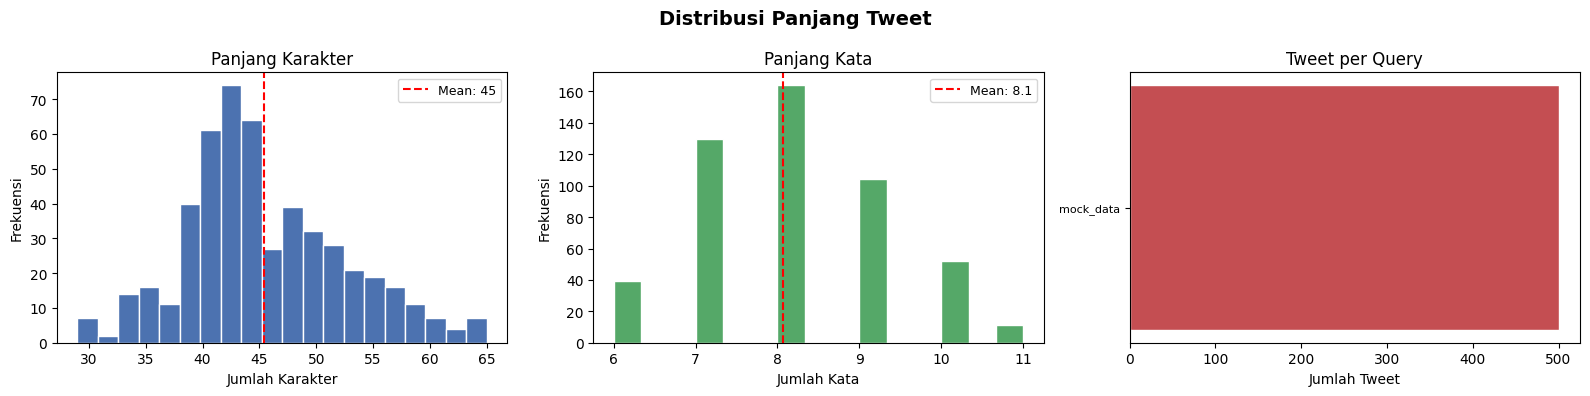

       char_len  word_len
count     500.0     500.0
mean       45.4       8.1
std         7.0       1.2
min        29.0       6.0
25%        41.0       7.0
50%        44.0       8.0
75%        50.0       9.0
max        65.0      11.0


In [50]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Distribusi Panjang Tweet', fontsize=14, fontweight='bold')

# Panjang karakter
axes[0].hist(df_tweets['char_len'], bins=20, color='#4C72B0', edgecolor='white')
axes[0].axvline(df_tweets['char_len'].mean(), color='red', linestyle='--',
                label=f"Mean: {df_tweets['char_len'].mean():.0f}")
axes[0].set_title('Panjang Karakter')
axes[0].set_xlabel('Jumlah Karakter')
axes[0].set_ylabel('Frekuensi')
axes[0].legend(fontsize=9)

# Panjang kata
axes[1].hist(df_tweets['word_len'], bins=15, color='#55A868', edgecolor='white')
axes[1].axvline(df_tweets['word_len'].mean(), color='red', linestyle='--',
                label=f"Mean: {df_tweets['word_len'].mean():.1f}")
axes[1].set_title('Panjang Kata')
axes[1].set_xlabel('Jumlah Kata')
axes[1].set_ylabel('Frekuensi')
axes[1].legend(fontsize=9)

# Tweet per query
query_counts = df_tweets['source_query'].value_counts().head(10)
axes[2].barh(range(len(query_counts)), query_counts.values, color='#C44E52', edgecolor='white')
axes[2].set_yticks(range(len(query_counts)))
axes[2].set_yticklabels([q[:25]+'...' if len(q)>25 else q for q in query_counts.index], fontsize=8)
axes[2].set_title('Tweet per Query')
axes[2].set_xlabel('Jumlah Tweet')

plt.tight_layout()
plt.show()

print(df_tweets[['char_len','word_len']].describe().round(1))

### Distribusi Entitas

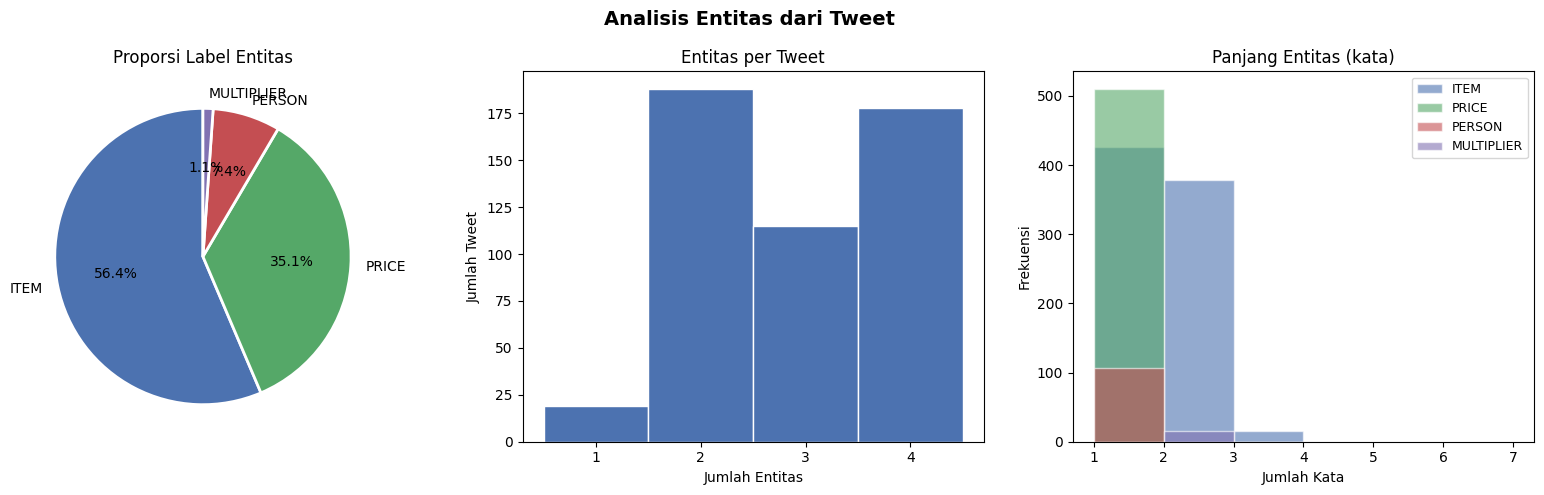


🔝 Top 10 ITEM:
  ██ beli (106x)
  █ total (47x)
   sarapan (40x)
   kenyang (33x)
   berdua (26x)
   makan siang (22x)
   tongseng (18x)
   nasi kuning (18x)
   nasi goreng (17x)
   wedang jahe (16x)

💰 Top 10 PRICE:
   gocap (22x)
   13rb (19x)
   38rb (19x)
   20k (18x)
   23rb (17x)
   15k (17x)
   50k (17x)
   24rb (17x)
   35k (17x)
   29rb (16x)


In [51]:
COLORS = {'ITEM':'#4C72B0','PRICE':'#55A868','PERSON':'#C44E52','MULTIPLIER':'#8172B2'}

# Flatten semua entitas
all_ents_tw = []
for rec in twitter_labeled:
    for ent in rec['entities']:
        all_ents_tw.append({'label': ent['label'], 'text': ent['text'],
                            'text_len': len(ent['text'].split())})
df_ents_tw = pd.DataFrame(all_ents_tw)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Analisis Entitas dari Tweet', fontsize=14, fontweight='bold')

# Pie chart
label_counts = df_ents_tw['label'].value_counts()
colors_pie   = [COLORS.get(l,'#999') for l in label_counts.index]
axes[0].pie(label_counts.values, labels=label_counts.index, autopct='%1.1f%%',
            colors=colors_pie, startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('Proporsi Label Entitas')

# Entitas per tweet
ent_per_tweet = [len(r['entities']) for r in twitter_labeled]
axes[1].hist(ent_per_tweet, bins=range(1, max(ent_per_tweet)+2),
             color='#4C72B0', edgecolor='white', align='left')
axes[1].set_title('Entitas per Tweet')
axes[1].set_xlabel('Jumlah Entitas')
axes[1].set_ylabel('Jumlah Tweet')
axes[1].set_xticks(range(1, max(ent_per_tweet)+1))

# Panjang entitas per label
for label in COLORS:
    subset = df_ents_tw[df_ents_tw['label']==label]['text_len']
    if not subset.empty:
        axes[2].hist(subset, bins=range(1,8), alpha=0.6,
                     label=label, color=COLORS[label], edgecolor='white')
axes[2].set_title('Panjang Entitas (kata)')
axes[2].set_xlabel('Jumlah Kata')
axes[2].set_ylabel('Frekuensi')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

print("\n🔝 Top 10 ITEM:")
for item, cnt in df_ents_tw[df_ents_tw['label']=='ITEM']['text'].value_counts().head(10).items():
    print(f"  {'█'*int(cnt*20/df_ents_tw['label'].value_counts().max())} {item} ({cnt}x)")

print("\n💰 Top 10 PRICE:")
for price, cnt in df_ents_tw[df_ents_tw['label']=='PRICE']['text'].value_counts().head(10).items():
    print(f"  {'█'*int(cnt*20/df_ents_tw['label'].value_counts().max())} {price} ({cnt}x)")

### WordCloud Tweet

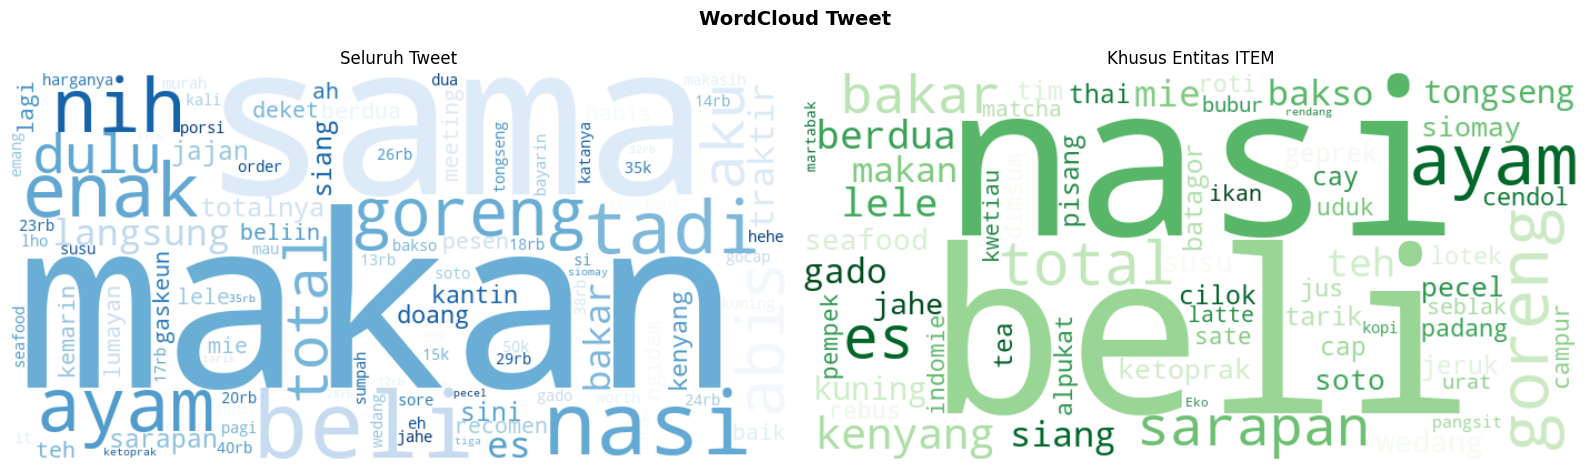

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('WordCloud Tweet', fontsize=14, fontweight='bold')

stopwords_id = {'yang','di','dan','ke','ini','itu','dengan','nya','ya',
                'aja','deh','sih','kalo','kalau','udah','udh','gak','ga',
                'engga','banget','juga','buat','dari','ada','bisa'}

# Semua teks
wc1 = WordCloud(width=700, height=350, background_color='white',
                colormap='Blues_r', max_words=100,
                collocations=False, stopwords=stopwords_id
               ).generate(" ".join(df_tweets['text'].tolist()))
axes[0].imshow(wc1, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Seluruh Tweet')

# Khusus entitas ITEM
item_text = " ".join(df_ents_tw[df_ents_tw['label']=='ITEM']['text'].tolist())
if item_text.strip():
    wc2 = WordCloud(width=700, height=350, background_color='white',
                    colormap='Greens_r', max_words=80, collocations=False
                   ).generate(item_text)
    axes[1].imshow(wc2, interpolation='bilinear')
    axes[1].axis('off')
    axes[1].set_title('Khusus Entitas ITEM')
else:
    axes[1].text(0.5, 0.5, 'Tidak ada data ITEM', ha='center', va='center')
    axes[1].axis('off')

plt.tight_layout()
plt.show()

### Kualitas Labeling

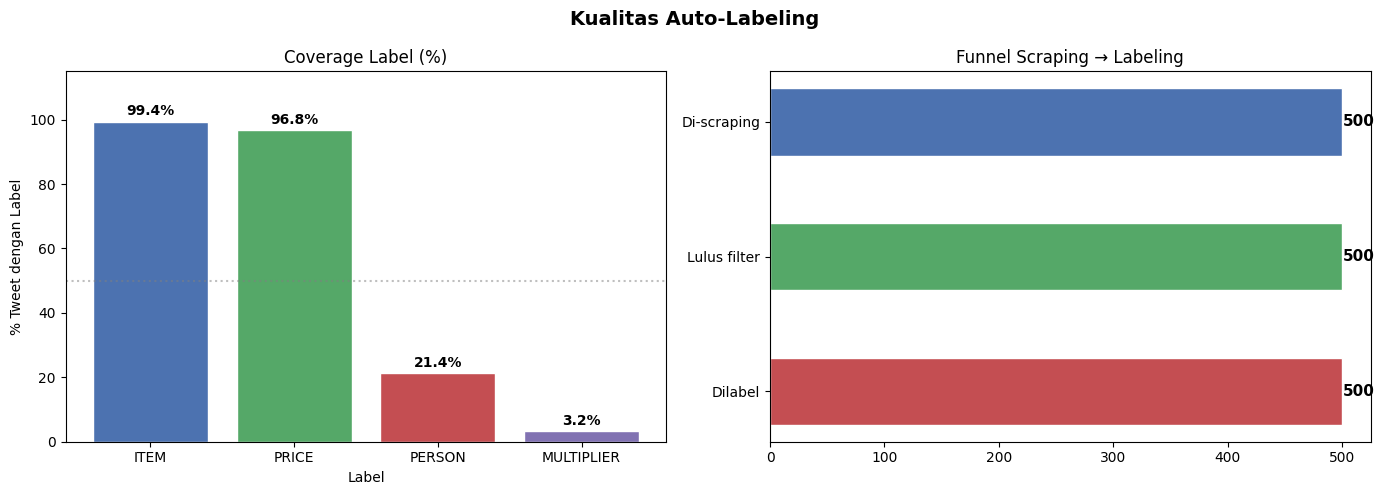


📋 Ringkasan:
  Coverage ITEM        : ███████████████████ 99.4%
  Coverage PRICE       : ███████████████████ 96.8%
  Coverage PERSON      : ████ 21.4%
  Coverage MULTIPLIER  :  3.2%


In [53]:
# Coverage per label
label_coverage = {}
for lbl in ['ITEM','PRICE','PERSON','MULTIPLIER']:
    count = sum(1 for r in twitter_labeled
                if any(e['label']==lbl for e in r['entities']))
    label_coverage[lbl] = count / len(twitter_labeled) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Kualitas Auto-Labeling', fontsize=14, fontweight='bold')

# Coverage bar
bars = axes[0].bar(label_coverage.keys(), label_coverage.values(),
                   color=[COLORS[l] for l in label_coverage], edgecolor='white')
for bar, val in zip(bars, label_coverage.values()):
    axes[0].text(bar.get_x()+bar.get_width()/2., bar.get_height()+1,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_title('Coverage Label (%)')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('% Tweet dengan Label')
axes[0].set_ylim(0, 115)
axes[0].axhline(50, color='gray', linestyle=':', alpha=0.5)

# Funnel
funnel_labels = ['Di-scraping','Lulus filter','Dilabel']
funnel_values = [labeling_stats['total_input'],
                 labeling_stats['labeled']+labeling_stats['filtered']//2,
                 labeling_stats['labeled']]
bars2 = axes[1].barh(range(3), funnel_values,
                      color=['#4C72B0','#55A868','#C44E52'], edgecolor='white', height=0.5)
for bar, val in zip(bars2, funnel_values):
    axes[1].text(val+1, bar.get_y()+bar.get_height()/2.,
                 str(val), va='center', fontsize=11, fontweight='bold')
axes[1].set_yticks(range(3))
axes[1].set_yticklabels(funnel_labels, fontsize=10)
axes[1].set_title('Funnel Scraping → Labeling')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("\n📋 Ringkasan:")
for lbl, pct in label_coverage.items():
    print(f"  Coverage {lbl:12s}: {'█'*int(pct/5)} {pct:.1f}%")

### Preview Hasil Labeling

In [54]:
def preview_entities(record):
    """Tampilkan teks dengan [ENTITAS|LABEL] untuk review manual."""
    text     = record['text']
    entities = sorted(record['entities'], key=lambda x: x['start'], reverse=True)
    annotated = text
    for ent in entities:
        s, e = ent['start'], ent['end']
        annotated = annotated[:s] + f"[{annotated[s:e]}|{ent['label']}]" + annotated[e:]
    return annotated

print("📄 Contoh 10 Tweet yang Sudah Dilabel:")
print("-" * 65)
sample = random.sample(twitter_labeled, min(10, len(twitter_labeled)))
for i, rec in enumerate(sample, 1):
    print(f"\n[{i}] {preview_entities(rec)}")
    summary = ', '.join([f"{e['text']} ({e['label']})" for e in rec['entities']])
    print(f"    → {summary}")

📄 Contoh 10 Tweet yang Sudah Dilabel:
-----------------------------------------------------------------

[1] kemarin [beli|ITEM] [ketoprak|ITEM] [20k|PRICE] buat [sarapan|ITEM], lumayan
    → beli (ITEM), ketoprak (ITEM), 20k (PRICE), sarapan (ITEM)

[2] [sarapan|ITEM] [ayam geprek|ITEM] [12rb|PRICE] sama [Tari|PERSON] tadi pagi
    → sarapan (ITEM), ayam geprek (ITEM), 12rb (PRICE), Tari (PERSON)

[3] [makan siang|ITEM] [cilok|ITEM] [gocap|PRICE] sama [Budi|PERSON] di kantin
    → makan siang (ITEM), cilok (ITEM), gocap (PRICE), Budi (PERSON)

[4] lagi ngidam [batagor|ITEM] nih totalnya [22rb|PRICE]
    → batagor (ITEM), 22rb (PRICE)

[5] abis meeting langsung makan [ketoprak|ITEM] [35k|PRICE]
    → ketoprak (ITEM), 35k (PRICE)

[6] makan [es teh|ITEM] [tiga porsi|MULTIPLIER] totalnya [20k|PRICE] [kenyang|ITEM] banget
    → es teh (ITEM), tiga porsi (MULTIPLIER), 20k (PRICE), kenyang (ITEM)

[7] abis makan [bakso urat|ITEM] sama [Hadi|PERSON] habis [13rb|PRICE] [berdua|ITEM]
    → bak

---
## 🔗 Merge Data Manual + Twitter → training_data.json

In [55]:
# =====================================================================
# MERGE DATA MANUAL (data_scraping) + DATA TWITTER
# =====================================================================

# Tambah field source ke data manual
for rec in data_scraping:
    rec.setdefault('source', 'manual')

# Gabungkan
combined = data_scraping + twitter_labeled
print(f"Data manual  : {len(data_scraping)}")
print(f"Data Twitter : {len(twitter_labeled)}")
print(f"Total gabung : {len(combined)}")

# Deduplikasi berdasarkan teks
seen_merge = set()
final_training = []
for rec in combined:
    key = rec['text'].strip().lower()
    if key not in seen_merge:
        seen_merge.add(key)
        final_training.append(rec)

print(f"Setelah dedup: {len(final_training)} (hapus {len(combined)-len(final_training)} duplikat)")

Data manual  : 10
Data Twitter : 500
Total gabung : 510
Setelah dedup: 509 (hapus 1 duplikat)


In [57]:
# =====================================================================
# SIMPAN KE outputs/training_data.json
# =====================================================================
import os

os.makedirs('outputs', exist_ok=True)
OUTPUT_PATH = 'outputs/training_data.json'

# Backup file lama jika ada
import os, json
from collections import Counter

os.makedirs('outputs', exist_ok=True)
OUTPUT_PATH = 'outputs/training_data.json'

# Simpan gabungan
with open(OUTPUT_PATH, 'w', encoding='utf-8') as f:
    json.dump(final_training, f, ensure_ascii=False, indent=2)

# Verifikasi
with open(OUTPUT_PATH) as f:
    check = json.load(f)

print(f"\n✅ training_data.json tersimpan: {len(check)} records")

# Distribusi sumber
src_dist = Counter(r.get('source','unknown') for r in check)
print(f"\n📋 Distribusi sumber:")
for src, cnt in src_dist.items():
    print(f"   {src:10s}: {cnt}")

# Simpan gabungan
with open(OUTPUT_PATH, 'w', encoding='utf-8') as f:
    json.dump(final_training, f, ensure_ascii=False, indent=2)

# Verifikasi
with open(OUTPUT_PATH) as f:
    check = json.load(f)

print(f"\n✅ training_data.json tersimpan: {len(check)} records")

# Distribusi sumber
src_dist = Counter(r.get('source','unknown') for r in check)
print(f"\n📋 Distribusi sumber:")
for src, cnt in src_dist.items():
    print(f"   {src:10s}: {cnt}")


✅ training_data.json tersimpan: 509 records

📋 Distribusi sumber:
   manual    : 10
   twitter   : 499

✅ training_data.json tersimpan: 509 records

📋 Distribusi sumber:
   manual    : 10
   twitter   : 499


### Perbandingan Sebelum vs Sesudah

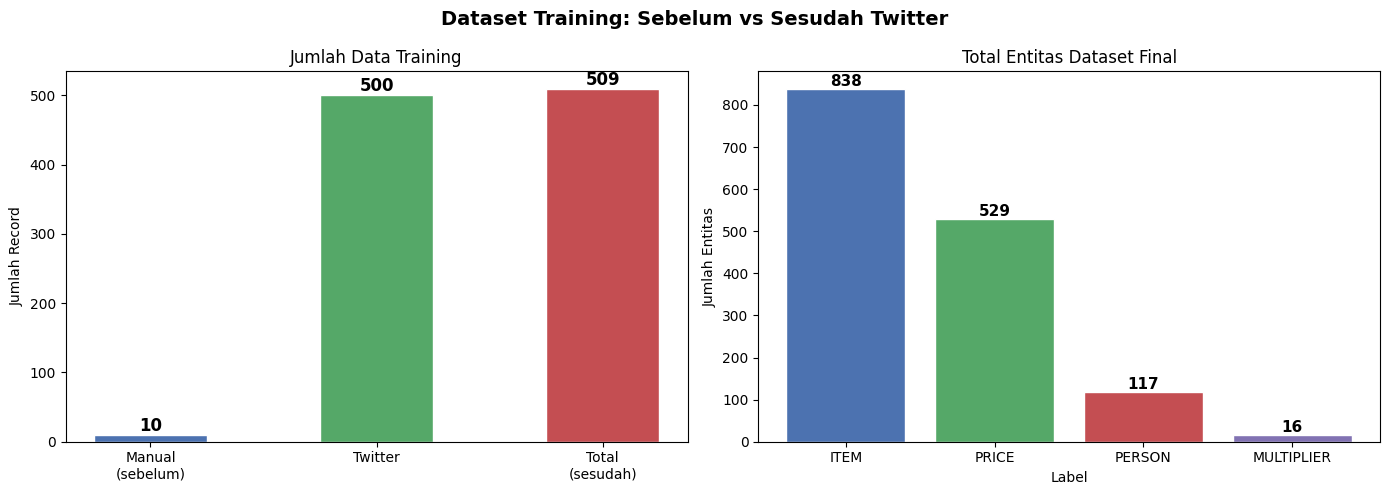

  ✅ SELESAI — TRAINING DATA SIAP
  Manual   : 10
  Twitter  : 500
  Total    : 509
  File     : outputs/training_data.json


In [58]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Dataset Training: Sebelum vs Sesudah Twitter', fontsize=14, fontweight='bold')

# Jumlah data
labels_bar = ['Manual\n(sebelum)', 'Twitter', 'Total\n(sesudah)']
values_bar = [len(data_scraping), len(twitter_labeled), len(final_training)]
colors_bar = ['#4C72B0', '#55A868', '#C44E52']
bars3 = axes[0].bar(labels_bar, values_bar, color=colors_bar, edgecolor='white', width=0.5)
for bar, val in zip(bars3, values_bar):
    axes[0].text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.3,
                 str(val), ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[0].set_title('Jumlah Data Training')
axes[0].set_ylabel('Jumlah Record')

# Distribusi entitas final
all_ents_final = Counter()
for rec in final_training:
    for ent in rec.get('entities', []):
        all_ents_final[ent['label']] += 1

axes[1].bar(all_ents_final.keys(), all_ents_final.values(),
            color=[COLORS.get(l,'#999') for l in all_ents_final], edgecolor='white')
for i, (lbl, cnt) in enumerate(all_ents_final.items()):
    axes[1].text(i, cnt+0.3, str(cnt), ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].set_title('Total Entitas Dataset Final')
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Jumlah Entitas')

plt.tight_layout()
plt.show()

print("=" * 55)
print("  ✅ SELESAI — TRAINING DATA SIAP")
print("=" * 55)
print(f"  Manual   : {len(data_scraping)}")
print(f"  Twitter  : {len(twitter_labeled)}")
print(f"  Total    : {len(final_training)}")
print(f"  File     : outputs/training_data.json")
print("=" * 55)